In [1]:
import pyart
import matplotlib.pyplot as plt
import numpy as np
import dateutil.parser as parser
import glob
import imageio as iio
from cartopy import crs, feature
import shapely.geometry as geom
import cartopy.io.shapereader as reader
import os
import shutil
import re
import pandas as pd
import geopandas as gpd
import requests
import boto3
import ast
import matplotlib.ticker as mticker

from botocore import UNSIGNED
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from botocore.config import Config
from matplotlib import colors, cm
from matplotlib.lines import Line2D
from shapely import wkt
from shapely.ops import unary_union
from datetime import datetime, timedelta, timezone
from pathlib import Path
from io import StringIO
from IPython import display
from os import name
from metpy.plots import USCOUNTIES


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



### To-Do

Dynamic Domain, SAMURAI integration, Storm Data Sync

In [27]:
### Colormaps

ref_colors = ['#4560A0', '#4E7EB3', '#5DABCE', '#69CDE2', '#11B80E', '#0D8107', '#296300', '#F9DE00', '#FF8400', '#FD0000', '#890000', '#0E0000', '#FFF4FF', '#FF73FF', '#AB00FB', '#6B00DA', '#05E1E5', '#000000']
ref_bounds = [-1, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 90]
ref_cmap = colors.ListedColormap(ref_colors)
ref_norm = colors.BoundaryNorm(ref_bounds, ref_cmap.N)

vel_colors = ['#FFFFFF', "#FFFD7C", '#FFFA00', "#FFE100", '#FF7E00', "#FF6200", '#E80000', '#AB0000', "#880000", '#531C1C', '#CCC9C9', "#005700", "#006F00", "#019401", "#00CD00", '#00FF3C', "#00FF7B",  "#00FFB7", '#00FFF7',  "#7DFFFB", '#FFFFFF']
vel_cmap = colors.LinearSegmentedColormap.from_list("vel_cmap", vel_colors)

kdp_colors = ['#767676', '#4B4B4B', '#4B0000', '#9F2037', '#CF6BA3', '#7B6A96', '#59EAE5', '#14B932', '#0AFF0A', '#ECEC00', '#EC6E12', '#EAB88C', '#FFFFFF']
kdp_bounds = [-2, -1, 0, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 8, 10]
kdp_cmap = colors.ListedColormap(kdp_colors)
kdp_norm = colors.BoundaryNorm(kdp_bounds, kdp_cmap.N)

zdr_colors = ['#000000', '#434343', '#8D8D8D', '#C7C7C7', '#76629E', '#04129F', '#218ECE', '#20CAA8', '#06DB24', '#FFFA5F', '#FF9848', '#D70000', '#820000', '#F786C0', '#FFFFFF']
zdr_bounds = [-4, -3, -2, -1, 0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 6]
zdr_cmap = colors.ListedColormap(zdr_colors)
zdr_norm = colors.BoundaryNorm(zdr_bounds, zdr_cmap.N)

sw_colors = ['#14034E', '#9C2CA6', '#E65059', '#FA7D22', '#CEFF18', '#64DC71', '#0095E1', '#00151F', '#FFFFFF']
sw_cmap = colors.LinearSegmentedColormap.from_list("sw_cmap", sw_colors)

cc_colors = ['#000000', '#2A2A35', '#54546B', '#575996', '#16148E', '#0D06D9', '#5EFD56', '#89D105', '#FFF400', '#FF8E00', '#FC1400', '#AA0400', '#970556']
cc_bounds = [0, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.92, 0.95, 0.97, 0.985, 1]
cc_cmap = colors.ListedColormap(cc_colors)
cc_norm = colors.BoundaryNorm(cc_bounds, cc_cmap.N)

In [28]:
### Helpers - Parsing

### Needed to parse list columns in the LSR and DAT dataframes, which may be stored as strings or lists. Needed for most functions inputting as a CSV.
def parse_list_col(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            y = ast.literal_eval(x)
            if isinstance(y, list):
                return y
        except Exception:
            pass
        return [x]
    return [x]

def local_file_path(file_path, out_dir="bulk"):
    base = Path(str(file_path)).name
    path = Path(out_dir) / base

    if path.is_file():
        return str(path)

    gz_path = Path(str(path) + ".gz")
    if gz_path.is_file():
        return str(gz_path)

    return str(path)

### Parse NEXRAD Filenames
# Inputs: input (str) - the file name of the radar data
# Outputs: title (str) - the title for the plot
#          dt_obj (datetime) - the datetime object parsed from the file name
#          file_name (str) - the base name of the input file


def _times_from_nexrad_file(path):
    name = os.path.basename(path)

    m = re.search(r"(?P<site>K[A-Z0-9]{3})(?P<date>\d{8})_(?P<time>\d{6})", name)

    if m is None:
        return pd.NaT, pd.NaT

    dt_start = pd.to_datetime(m.group("date") + m.group("time"), format="%Y%m%d%H%M%S", errors="coerce")
    dt_end = dt_start + pd.Timedelta(minutes=5)

    return dt_start, dt_end

def _parse_nexrad_name(file_path):
    name = Path(file_path).name

    pat = re.compile(r"^(?P<site>K[A-Z0-9]{3})(?P<date>\d{8})_(?P<time>\d{6})(?:_V\d+)?(?:\..*)?$")

    m = pat.match(name)

    if m:
        dt_start = datetime.strptime(f"{m.group('date')}{m.group('time')}", "%Y%m%d%H%M%S")
        dt_end = dt_start + timedelta(minutes=5)
        return pd.Timestamp(dt_start), pd.Timestamp(dt_end), "NEXRAD"

    return None, None, None

def parse_bulk(start, end):
    # Attempt to parse the start and end datetime strings into datetime objects
    try:
        dt_start = parser.parse(start)
        dt_end = parser.parse(end)
    except:
        print("Error: Invalid date format. Please use 'YYYYMMDDTHHMMSS' format.")
        return []
    all_files = glob.glob('bulk/K*') # Glob together NEXRAD files
    in_range = list() # Initialize an empty list to hold the in-range files
    for file in all_files: # Find in-range files
        name = Path(file).name
        time_str = name.split('.')[1] # Obtain starting datetime from each file
        file_dt = datetime.strptime(time_str, "%Y%m%d_%H%M%S") # Parse the datetime string into a datetime object
        if dt_start <= file_dt <= dt_end: # Check if the file's datetime falls within the specified range
            in_range.append(file)
    return in_range

def parse_file(input_file, alt=False, sweep=False):
    file_name = os.path.basename(str(input_file))
    
    m = re.search(r"(?P<site>K[A-Z0-9]{3})(?P<date>\d{8})_(?P<time>\d{6})", file_name)

    if m:
        radar = m.group("site")
        dt_obj = datetime.strptime(
            m.group("date") + m.group("time"),
            "%Y%m%d%H%M%S"
        )
    else:
        radar = "NEXRAD"
        dt_obj = pd.NaT

    if pd.isna(dt_obj):
        title_time = "Unknown Time"
    else:
        title_time = dt_obj.strftime("%Y-%m-%d %H:%M:%S")

    if alt:
        title = f"{radar} Radar Data from {title_time}\nAltitude {alt}m"
        stem = Path(file_name).stem
        file_name = f"{stem}_CAPPIh{alt}.png"

    elif sweep is not False:
        title = f"{radar} Radar Data from {title_time}\nSweep {sweep}"
        stem = Path(file_name).stem
        file_name = f"{stem}_PPIs{sweep}.png"

    else:
        title = f"{radar} Radar Data from {title_time}"
        stem = Path(file_name).stem
        file_name = f"{stem}_ref.png"

    return title, dt_obj, file_name

def get_radar_location(site, nexrad_csv="nexrad.csv"):
    ref_sites = pd.read_csv(nexrad_csv)
    row = ref_sites.loc[ref_sites["site"] == site]
    if row.empty:
        return None, None
    return float(row.iloc[0]["lon"]), float(row.iloc[0]["lat"])

def make_clean_out_path(input_file, out_dir="clean", cappi_alt=False):
    p = Path(input_file)

    raw_stem = p.name
    if raw_stem.endswith(".gz"):
        raw_stem = raw_stem[:-3]
    if raw_stem.endswith(".nc"):
        raw_stem = raw_stem[:-3]

    if cappi_alt is not False and cappi_alt is not None:
        clean_file_name = f"{Path(raw_stem).stem}_cappi{int(cappi_alt)}_clean.nc"
    else:
        clean_file_name = f"{Path(raw_stem).stem}_clean.nc"

    return Path(out_dir) / clean_file_name

In [55]:
### Helpers - Display
 
### Site markers 
# Inputs: ax (matplotlib.axes) - From plotting functions 
#         sites (list) - List of radar sides 
#         buffer_deg (float) - Distance of the radar site buffer in degrees 
 
### Helper - Ensure directory exists before saving files
def ensure_dir_exists(file_path):
    """
    Ensure the directory for a file path exists. Creates it if it doesn't.

    Args:
        file_path: Path to the file (directory will be extracted and created)

    Returns:
        file_path (unchanged)
    """
    file_path = str(file_path)
    dir_path = os.path.dirname(file_path)

    # Only create if there's a directory component
    if dir_path and not os.path.exists(dir_path):
        os.makedirs(dir_path, exist_ok=True)

    return file_path


def add_site_markers(ax, sites, buffer_deg):
    for _, row in sites.iterrows():
        site = row["site"]
        lon = row["lon"]
        lat = row["lat"]
        circle = plt.Circle((lon, lat), radius=buffer_deg, fill=False, zorder=30, color="blue", transform=crs.PlateCarree())
        ax.add_patch(circle)
        ax.scatter(lon, lat, s=30, marker="*", zorder=5, color="green", transform=crs.PlateCarree())
        ax.text(
            lon,
            lat,
            site,
            transform=crs.PlateCarree(),
            color="red",
            fontsize=8,
            ha="left",
            va="bottom",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.5, boxstyle="round,pad=0.2"),
            zorder=20,
        )


def overlay_reports(ax, radar_lon, radar_lat, lsr_df=None, dat_df=None, sd_df=None):
    if radar_lon is not None and radar_lat is not None:
        ax.plot(radar_lon, radar_lat, marker="*", markersize=6, color="green", transform=crs.PlateCarree(), zorder=20)

    if lsr_df is not None and not lsr_df.empty:
        lsr_plot = lsr_df.rename(columns={"LAT": "lat", "LON": "lon"}).copy()
        lsr_plot["lat"] = pd.to_numeric(lsr_plot.get("lat"), errors="coerce")
        lsr_plot["lon"] = pd.to_numeric(lsr_plot.get("lon"), errors="coerce")
        lsr_plot = lsr_plot.dropna(subset=["lat", "lon"])
        if not lsr_plot.empty:
            ax.scatter(
                lsr_plot["lon"],
                lsr_plot["lat"],
                s=20,
                marker="o",
                color="green",
                edgecolors="black",
                linewidths=0.4,
                transform=crs.PlateCarree(),
                zorder=16,
            )

    if dat_df is not None and not dat_df.empty:
        dat_plot = dat_df.rename(columns={"LAT": "lat", "LON": "lon"}).copy()
        dat_plot["lat"] = pd.to_numeric(dat_plot.get("lat"), errors="coerce")
        dat_plot["lon"] = pd.to_numeric(dat_plot.get("lon"), errors="coerce")
        dat_plot = dat_plot.dropna(subset=["lat", "lon"])

        ef = pd.to_numeric(dat_plot.get("efscale"), errors="coerce")
        tor_df = dat_plot[ef >= 0].copy()
        wind_df = dat_plot[ef == -1].copy()

        if not tor_df.empty:
            ax.scatter(
                tor_df["lon"],
                tor_df["lat"],
                s=25,
                marker="^",
                color="red",
                edgecolors="black",
                linewidths=0.2,
                transform=crs.PlateCarree(),
                zorder=19,
            )

        if not wind_df.empty:
            ax.scatter(
                wind_df["lon"],
                wind_df["lat"],
                s=20,
                marker="s",
                color="blue",
                edgecolors="black",
                linewidths=0.2,
                transform=crs.PlateCarree(),
                zorder=17,
            )

    if sd_df is not None and not sd_df.empty:
        sd_plot = sd_df.rename(columns={"LAT": "lat", "LON": "lon"}).copy()
        sd_plot["lat"] = pd.to_numeric(sd_plot.get("lat"), errors="coerce")
        sd_plot["lon"] = pd.to_numeric(sd_plot.get("lon"), errors="coerce")
        sd_plot = sd_plot.dropna(subset=["lat", "lon"])

        tor_df = sd_plot[sd_plot["EVENT_TYPE"] == "Tornado"].copy()
        wind_df = sd_plot[sd_plot["EVENT_TYPE"] == "Wind"].copy()
        hail_df = sd_plot[sd_plot["EVENT_TYPE"] == "Hail"].copy()

        if not tor_df.empty:
            ax.scatter(
                tor_df["lon"],
                tor_df["lat"],
                s=25,
                marker="^",
                color="red",
                edgecolors="grey",
                linewidths=0.2,
                transform=crs.PlateCarree(),
                zorder=18,
            )

        if not wind_df.empty:
            ax.scatter(
                wind_df["lon"],
                wind_df["lat"],
                s=20,
                marker="s",
                color="blue",
                edgecolors="grey",
                linewidths=0.2,
                transform=crs.PlateCarree(),
                zorder=18,
            )
        
        if not hail_df.empty:
            ax.scatter(
                hail_df["lon"],
                hail_df["lat"],
                s=20,
                marker="o",
                color="green",
                edgecolors="grey",
                linewidths=0.2,
                transform=crs.PlateCarree(),
                zorder=18,
            )


def add_reports_legend(fig, include_lsr=True, include_dat=True, include_sd=True):
    legend_handles = [
        Line2D([0], [0], marker="*", color="none", markerfacecolor="green", markeredgecolor="black", markersize=9, label="Radar"),
    ]

    if include_lsr:
        legend_handles.append(
            Line2D([0], [0], marker="o", color="none", markerfacecolor="green", markeredgecolor="black", markersize=7, label="LSR Hail")
        )

    if include_dat:
        legend_handles.extend([
            Line2D([0], [0], marker="^", color="none", markerfacecolor="red", markeredgecolor="black", markersize=8, label="DAT Tornado"),
            Line2D([0], [0], marker="s", color="none", markerfacecolor="blue", markeredgecolor="black", markersize=7, label="DAT Wind"),
        ])

    if include_sd:
        legend_handles.extend([
            Line2D([0], [0], marker="^", color="none", markerfacecolor="red", markeredgecolor="grey", markersize=7, label="SD Tornado"),
            Line2D([0], [0], marker="o", color="none", markerfacecolor="green", markeredgecolor="grey", markersize=7, label="SD Hail"),
            Line2D([0], [0], marker="s", color="none", markerfacecolor="blue", markeredgecolor="grey", markersize=7, label="SD Wind")
        ])

    fig.legend(handles=legend_handles, loc="lower center", ncol=max(2, len(legend_handles)), fontsize=9, framealpha=0.8, bbox_to_anchor=(0.5, 0.01))


# Backward-compatible wrappers

def overlay_lsr_dat(ax, radar_lon, radar_lat, lsr_df, dat_df):
    overlay_reports(ax, radar_lon, radar_lat, lsr_df=lsr_df, dat_df=dat_df, sd_df=None)


def add_LSRDAT_legend(fig):
    add_reports_legend(fig, include_lsr=True, include_dat=True, include_sd=False)


# Extent can be a symmetric radar-centered range in km, or side-specific km offsets.
def rad_extent(ax, clean_rad, extent):
    if extent is None:
        return

    if isinstance(extent, (int, float)):
        extent = {"left": extent, "right": extent, "bottom": extent, "top": extent}

    required_keys = {"left", "right", "bottom", "top"}

    if not isinstance(extent, dict) or not required_keys.issubset(extent):
        raise ValueError(
            "extent must be a number in km or a dictionary with keys "
            "'left', 'right', 'bottom', and 'top'"
        )

    lat0 = float(clean_rad.latitude["data"][0])
    lon0 = float(clean_rad.longitude["data"][0])

    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.deg2rad(lat0))

    left_km = float(extent["left"])
    right_km = float(extent["right"])
    bottom_km = float(extent["bottom"])
    top_km = float(extent["top"])

    map_extent = [
        lon0 - left_km / km_per_deg_lon,
        lon0 + right_km / km_per_deg_lon,
        lat0 - bottom_km / km_per_deg_lat,
        lat0 + top_km / km_per_deg_lat,
    ]

    ax.set_extent(map_extent, crs=crs.PlateCarree())

In [ ]:
### Helpers - Renderers

### renders quick reflectivity PNGs in the user-defined window from obtain_filtered_files(...)
def window_render(window_df, site, start_dt, end_dt, frame_dir="images", out_dir="bulk",
                  cappi_alt=False, sweep=0, mode='quickprod', product='reflectivity',
                  gdf_lsr=None, gdf_dat=None, gdf_sd=None, extent=None):

    start_dt = pd.Timestamp(start_dt)
    end_dt = pd.Timestamp(end_dt)

    df = window_df.copy()
    df["dt_start"] = pd.to_datetime(df["dt_start"], errors="coerce")
    df["dt_end"] = pd.to_datetime(df["dt_end"], errors="coerce")

    if "site" not in df.columns and "window_site" in df.columns:
        df["site"] = df["window_site"]

    window_df = df[
        (df["site"].astype(str).str.upper() == str(site).upper()) &
        (df["dt_end"] >= start_dt) &
        (df["dt_start"] <= end_dt)
    ].copy()

    if window_df.empty:
        print(f"No downloaded files found for {site}: {start_dt} to {end_dt}")
        print("Available sites:", sorted(df["site"].dropna().astype(str).unique()))
        print("Available time range:", df["dt_start"].min(), "to", df["dt_end"].max())
        return []

    # --- Filter by mode ---
    file_names = (
        window_df["file"]
        .astype(str)
        .str.replace("\\", "/", regex=False)
        .str.rsplit("/", n=1)
        .str[-1]
    )

    if mode == "rhi":
        window_df = window_df[file_names.str.endswith("_RHI.nc", na=False)].copy()

    if window_df.empty:
        print(f"No matching {mode.upper()} files for {site}: {start_dt} to {end_dt}")
        return []

    window_df = window_df.sort_values("dt_start").reset_index(drop=True)

    os.makedirs(frame_dir, exist_ok=True)

    radar_lon, radar_lat = get_radar_location(site)
    frame_paths = []

    # Keep dataset legend handles stable for all frames in this window.
    legend_lsr_df, legend_dat_df, legend_sd_df = get_frame_reports(
        site=site,
        window_start=start_dt,
        frame_time=end_dt,
        gdf_lsr=gdf_lsr,
        gdf_dat=gdf_dat,
        gdf_sd=gdf_sd,
        cumulative=True
    )
    legend_include = {
        "lsr": not legend_lsr_df.empty,
        "dat": not legend_dat_df.empty,
        "sd": not legend_sd_df.empty,
    }

    for i, row in window_df.iterrows():
        raw_file = Path(str(row["file"]))

        if raw_file.is_file():
            file_path = str(raw_file)
        else:
            file_path = local_file_path(row["file"], out_dir=out_dir)

        frame_time = pd.Timestamp(row["dt_start"])

        print(f"\nRendering {site} frame {i+1}/{len(window_df)}: {file_path}")

        if not Path(file_path).is_file():
            print(f"Skipping missing local file: {file_path}")
            continue

        try:
            if str(file_path).endswith(".nc"):
                rad = pyart.io.read_cfradial(file_path)
            else:
                rad = pyart.io.read_nexrad_archive(file_path)
        except Exception as e:
            print(f"Skipping unreadable file {file_path}: {e}")
            continue

        lsr_frame, dat_frame, sd_frame = get_frame_reports(
            site=site,
            window_start=start_dt,
            frame_time=frame_time,
            gdf_lsr=gdf_lsr,
            gdf_dat=gdf_dat,
            gdf_sd=gdf_sd,
            cumulative=True
        )

        if mode == 'quickprod':
            frame_name = f"{site}_PPI_{frame_time:%Y%m%dT%H%M%S}_{i:03d}.png"
            out_path = os.path.join(frame_dir, frame_name)

            rad_quickprod(
                file_path, product, extent=extent, cappi_alt=cappi_alt, sweep=sweep, out_path=out_path,
                site=site, radar_lon=radar_lon, radar_lat=radar_lat,
                lsr_df=lsr_frame, dat_df=dat_frame, sd_df=sd_frame, legend_include=legend_include
            )
            frame_paths.append(out_path)

        elif mode == 'detailed':
            frame_name = f"{site}_PPI_{frame_time:%Y%m%dT%H%M%S}_{i:03d}.png"
            out_path = os.path.join(frame_dir, frame_name)

            rad_multidisplay(
                file_path, extent=extent, cappi_alt=cappi_alt, sweep=sweep, rad_dir=out_dir,
                remake_clean=False, radar_lon=radar_lon, radar_lat=radar_lat,
                lsr_df=lsr_frame, dat_df=dat_frame, sd_df=sd_frame, out_path=out_path,
                legend_include=legend_include
            )
            frame_paths.append(out_path)

        elif mode == 'rhi':
            for sweep_num in range(rad.nsweeps):
                sweep_out_name = (
                    f"{site}_RHI_"
                    f"{frame_time:%Y%m%dT%H%M%S}_"
                    f"sweep{sweep_num:02d}_"
                    f"{i:03d}.png"
                )
                sweep_out_path = os.path.join(frame_dir, sweep_out_name)

                rad_multirhi(
                    file_path,
                    sweep=sweep_num,
                    rad_dir=out_dir,
                    out_path=sweep_out_path
                )

                frame_paths.append(sweep_out_path)

            continue
    return frame_paths


### obtains a GIF from the frame paths given from window_render(...)
def gif_from_frames(frame_paths, gif_path='GIFs', duration=0.5):
    if not frame_paths:
        print(f"No frames available for GIF: {gif_path}")
        return None

    images = [iio.imread(frame) for frame in frame_paths]
    ensure_dir_exists(gif_path)
    iio.mimwrite(gif_path, images, duration=duration, loop=0)
    print(f"Saved GIF: {gif_path}")
    return gif_path


def get_frame_reports(site, window_start, frame_time, gdf_lsr=None, gdf_dat=None, gdf_sd=None, cumulative=True):
    lsr_frame = pd.DataFrame()
    dat_frame = pd.DataFrame()
    sd_frame = pd.DataFrame()

    if gdf_lsr is not None and not gdf_lsr.empty:
        lsr = gdf_lsr.copy().rename(columns={"LAT": "lat", "LON": "lon"})
        lsr["dt_start"] = pd.to_datetime(lsr["dt_start"], errors="coerce")
        if "valid_sites" in lsr.columns:
            lsr["valid_sites"] = lsr["valid_sites"].apply(parse_list_col)
            lsr = lsr[lsr["valid_sites"].apply(lambda s: site in s)]

        if cumulative:
            lsr = lsr[(lsr["dt_start"] >= window_start) & (lsr["dt_start"] <= frame_time)]
        else:
            lsr = lsr[lsr["dt_start"] == frame_time]

        lsr_frame = lsr.copy()

    if gdf_dat is not None and not gdf_dat.empty:
        dat = gdf_dat.copy().rename(columns={"LAT": "lat", "LON": "lon"})
        dat_dt_col = "dt_valid" if "dt_valid" in dat.columns else "stormdate"
        dat[dat_dt_col] = pd.to_datetime(dat[dat_dt_col], errors="coerce")
        if "valid_sites" in dat.columns:
            dat["valid_sites"] = dat["valid_sites"].apply(parse_list_col)
            dat = dat[dat["valid_sites"].apply(lambda s: site in s)]

        if cumulative:
            dat = dat[(dat[dat_dt_col] >= window_start) & (dat[dat_dt_col] <= frame_time)]
        else:
            dat = dat[dat[dat_dt_col] == frame_time]

        dat_frame = dat.copy()

    if gdf_sd is not None and not gdf_sd.empty:
        sd = gdf_sd.copy().rename(columns={"LAT": "lat", "LON": "lon"})
        sd["dt_valid"] = pd.to_datetime(sd["dt_valid"], errors="coerce")
        if "valid_sites" in sd.columns:
            sd["valid_sites"] = sd["valid_sites"].apply(parse_list_col)
            sd = sd[sd["valid_sites"].apply(lambda s: site in s)]

        if cumulative:
            sd = sd[(sd["dt_valid"] >= window_start) & (sd["dt_valid"] <= frame_time)]
        else:
            sd = sd[sd["dt_valid"] == frame_time]

        sd_frame = sd.copy()

    return lsr_frame, dat_frame, sd_frame

In [31]:
### Helpers - Radar Object

### Filter Radar Object and Write
# Inputs: rad_obj (Radar) - the radar object containing the raw radar data
#         input_file (str) - the file name of the raw radar data
# Outputs: None (writes a new netCDF file with the filtered radar data)

def make_cappi_grid(rad_obj, cappi_alt,
                    fields=None,
                    xlim=(-100000, 100000),
                    ylim=(-100000, 100000),
                    zlim=(0, 10000),
                    dx=1000,
                    dz=500):
    if fields is None:
        fields = [
            "reflectivity",
            "corrected_velocity",
            "velocity",
            "differential_reflectivity",
            "specific_differential_phase"
        ]

    fields = [f for f in fields if f in rad_obj.fields]

    nz = int((zlim[1] - zlim[0]) / dz) + 1
    ny = int((ylim[1] - ylim[0]) / dx) + 1
    nx = int((xlim[1] - xlim[0]) / dx) + 1

    grid = pyart.map.grid_from_radars(
        rad_obj,
        fields=fields,
        grid_shape=(nz, ny, nx),
        grid_limits=(zlim, ylim, xlim),
        weighting_function="Barnes2"
    )

    z_vals = grid.z["data"]
    z_idx = int(np.argmin(np.abs(z_vals - cappi_alt)))

    grid_lon = grid.point_longitude["data"][z_idx]
    grid_lat = grid.point_latitude["data"][z_idx]

    print(f"Requested CAPPI altitude: {cappi_alt}")
    print(f"Using grid level: {z_vals[z_idx]} m")
    print(f"Using z index: {z_idx}")

    return grid, grid_lon, grid_lat, z_idx

def get_cappi_slice(grid, field, cappi_alt):
    z_vals = grid.z["data"]
    z_idx = int(np.argmin(np.abs(z_vals - cappi_alt)))

    print("Requested CAPPI altitude:", cappi_alt)
    print("Using grid level:", z_vals[z_idx])
    print("Using z index:", z_idx)

    data = grid.fields[field]["data"][z_idx]
    lon = grid.point_longitude["data"][z_idx]
    lat = grid.point_latitude["data"][z_idx]

    return lon, lat, data, z_idx

def rad_init(rad_obj, out_path, cappi_alt=False, RHI=False):
    gatefilter = pyart.correct.GateFilter(rad_obj)
    gatefilter.exclude_invalid("differential_phase")
    gatefilter.exclude_below("reflectivity", 15)
    gatefilter.exclude_below("cross_correlation_ratio", 0.3)

    try:
        vel = pyart.correct.dealias_region_based(
            rad_obj,
            vel_field="velocity",
            keep_original=False,
            gatefilter=gatefilter,
            centered=True
        )
        rad_obj.add_field("corrected_velocity", vel, replace_existing=True)
    except Exception as e:
        print(f"Error in dealiasing velocity: {e}")

    kdp_vulpiani = pyart.retrieve.kdp_vulpiani(
        rad_obj,
        gatefilter=gatefilter,
        phidp_field="differential_phase",
        kdp_field="specific_differential_phase",
        band='C')

    kdp_dict = kdp_vulpiani[0]
    kdp_data = np.ma.masked_invalid(kdp_dict["data"])
    combined_mask = np.ma.getmaskarray(kdp_data) | gatefilter.gate_excluded

    kdp_dict["data"] = np.ma.array(kdp_data, mask=combined_mask)
    rad_obj.add_field("specific_differential_phase", kdp_dict, replace_existing=True)

    ensure_dir_exists(out_path)
    pyart.io.write_cfradial(out_path, rad_obj)

def rad_pathfinding(file_path, rad_dir):
    
    file_path = Path(file_path)

    if file_path.is_file():
        raw_path = file_path
    else:
        raw_path = Path(rad_dir) / file_path.name

    if not raw_path.is_file():
        gz_path = Path(str(raw_path) + ".gz")
        nc_path = raw_path.with_suffix(".nc")

        if gz_path.is_file():
            raw_path = gz_path
        elif nc_path.is_file():
            raw_path = nc_path
        else:
            raise FileNotFoundError(f"Radar file not found: {raw_path}")

    if "cfrad" in raw_path.name:
        raw_rad = pyart.io.read_cfradial(str(raw_path))
    else:
        raw_rad = pyart.io.read_nexrad_archive(str(raw_path))

    return raw_rad, raw_path


In [32]:
### Display - LSR/DAT/SD Sync-range GIF
def sync_range_images(sync_ranges, gif_dir="GIFs", frame_dir="images", gif=False,
                      out_dir="bulk", duration=0.7, cappi_alt=False, sweep=0,
                      mode='quickprod', extent=None, gdf_lsr=None, gdf_dat=None, gdf_sd=None):

    if isinstance(sync_ranges, str):
        df_window = pd.read_csv(sync_ranges)
    else:
        df_window = sync_ranges.copy()

    df_window = df_window.loc[:, ~df_window.columns.str.contains(r"^Unnamed")]

    for col in ["dt_start", "dt_end", "window_start", "window_end"]:
        if col in df_window.columns:
            df_window[col] = pd.to_datetime(df_window[col], errors="coerce")

    if "site" not in df_window.columns and "window_site" in df_window.columns:
        df_window["site"] = df_window["window_site"]

    all_outputs = {}

    if cappi_alt not in (False, None):
        cappi_list = cappi_alt if isinstance(cappi_alt, (list, tuple, set)) else [cappi_alt]
    else:
        cappi_list = [False]

    for alt in cappi_list:
        this_df = df_window.copy()

        if alt not in (False, None):
            alt_label = f"cappi{int(alt)}"

        else:
            scan_types = []
            if "type" in this_df.columns:
                scan_types = (
                    this_df["type"]
                    .dropna()
                    .astype(str)
                    .str.upper()
                    .unique()
                    .tolist()
                )

            if len(scan_types) == 1:
                alt_label = scan_types[0].lower()
            else:
                alt_label = f"sweep{sweep}"

        this_frame_dir = os.path.join(frame_dir, alt_label)
        this_gif_dir = os.path.join(gif_dir, alt_label)

        os.makedirs(this_frame_dir, exist_ok=True)
        os.makedirs(this_gif_dir, exist_ok=True)

        unique_windows = (
            this_df[["site", "window_start", "window_end"]]
            .dropna()
            .drop_duplicates()
            .sort_values(["site", "window_start"])
            .reset_index(drop=True)
        )

        output_paths = []

        for site, start_dt, end_dt in unique_windows.itertuples(index=False, name=None):
            print(f"\nProcessing {site}: {start_dt} to {end_dt} ({alt_label})")

            this_window_df = this_df[
                (this_df["site"].astype(str).str.upper() == str(site).upper()) &
                (this_df["window_start"] == start_dt) &
                (this_df["window_end"] == end_dt)
            ].copy()

            frame_paths = window_render(
                this_window_df,
                site,
                start_dt,
                end_dt,
                frame_dir=this_frame_dir,
                out_dir=out_dir,
                cappi_alt=alt,
                sweep=sweep,
                mode=mode,
                extent=extent,
                gdf_lsr=gdf_lsr,
                gdf_dat=gdf_dat,
                gdf_sd=gdf_sd,
            )

            if not frame_paths:
                print(f"No frames created for {site}: {start_dt} to {end_dt}")
                continue

            if gif:
                gif_name = f"{site}_{alt_label}_{start_dt:%Y%m%dT%H%M%S}_{end_dt:%Y%m%dT%H%M%S}.gif"
                gif_path = os.path.join(this_gif_dir, gif_name)

                gif_out = gif_from_frames(frame_paths=frame_paths, gif_path=gif_path, duration=duration)

                if gif_out is not None:
                    output_paths.append(gif_out)
            else:
                output_paths.extend(frame_paths)

        all_outputs[alt_label] = output_paths

    return all_outputs

In [60]:
### Display - Multi-panel PPI/CAPPI display of radar fields
# Inputs: rad_str (str) - radar filename, e.g. 'KMKX20250515_224202_V06'
#         alt (bool/int) - CAPPI altitude if desired, otherwise False
#         sweep (int) - sweep number for PPI plotting
#         rad_dir (str) - directory containing raw radar files
#         extent (list/tuple) - optional map extent [lonmin, lonmax, latmin, latmax]
#         remake_clean (bool) - remake cleaned CFRadial file?
# Outputs: None (saves a multi-panel radar image)

def rad_multidisplay(file_path, extent=None, cappi_alt=False, sweep=0, rad_dir='bulk',
                     remake_clean=False, radar_lon=None, radar_lat=None, lsr_df=None, dat_df=None, sd_df=None, out_path=None,
                     legend_include=None):

    raw_rad, raw_path = rad_pathfinding(file_path, rad_dir)

    projection = crs.LambertConformal(central_latitude=raw_rad.latitude["data"][0], central_longitude=raw_rad.longitude["data"][0])

    states = feature.NaturalEarthFeature(category="cultural", name="admin_1_states_provinces_lines", scale="50m", facecolor="none")

    title, _, image_file_name = parse_file(file_path, alt=cappi_alt, sweep=sweep)

    clean_path = make_clean_out_path(raw_path, out_dir="clean", cappi_alt=cappi_alt)

    if out_path is None:
        image_path = Path("images") / image_file_name
    else:
        image_path = Path(out_path)

    if remake_clean and clean_path.is_file():
        clean_path.unlink()

    if not clean_path.is_file():
        try:
            rad_init(raw_rad, clean_path, cappi_alt=cappi_alt)
        except Exception as e:
            print(f"Error initializing radar: {e}")
            return

    clean_rad = pyart.io.read_cfradial(clean_path)

    is_cappi = cappi_alt not in (False, None)

    if is_cappi:
        cappi_result = make_cappi_grid(clean_rad, cappi_alt)

        if isinstance(cappi_result, tuple):
            grid, grid_lon, grid_lat, z_idx = cappi_result
        else:
            raise TypeError(
                "make_cappi_grid must return: grid, grid_lon, grid_lat, z_idx"
            )

        chosen_sweep = 0
        display_for_plot = None

    else:
        grid = None
        grid_lon = None
        grid_lat = None
        z_idx = None

        display_for_plot = pyart.graph.RadarMapDisplay(
            clean_rad,
            shift=(0, 0),
            grid_projection=projection
        )

    if radar_lon is None:
        radar_lon = float(clean_rad.longitude["data"][0])

    if radar_lat is None:
        radar_lat = float(clean_rad.latitude["data"][0])

    print(f"Clean radar fields: {list(clean_rad.fields.keys())}")

    clean_display = pyart.graph.RadarMapDisplay(clean_rad, shift=(0, 0), grid_projection=projection)

    # Everything is now assumed to come from the cleaned radar object.
    # Format:
    # field_key: [subplot_index, panel_title, colorbar_label, cmap, norm, possible_field_names]
    ax_dict = {
        "reflectivity": [221, "Reflectivity", r"$Z_h$ (dBZ)", ref_cmap, ref_norm, ["reflectivity", "DBZ"]],
        "velocity": [222, "Velocity", r"$V_r$ (m s$^{-1}$)", vel_cmap, None, ["corrected_velocity", "unfolded_velocity", "velocity", "VEL"]],
        "differential_reflectivity": [223, "Differential Reflectivity", r"$Z_{DR}$ (dB)", zdr_cmap, zdr_norm, ["differential_reflectivity", "ZDR"]],
        "specific_differential_phase": [224, "Specific Differential Phase", r"$K_{DP}$ (deg km$^{-1}$)", kdp_cmap, kdp_norm, ["specific_differential_phase", "KDP", "KDP_maesaka"]]
    }

    def sweep_has_valid_data(radar, field_name, sweep_num):
        try:
            if int(sweep_num) >= int(radar.nsweeps):
                return False

            slc = radar.get_slice(int(sweep_num))
            data = radar.fields[field_name]["data"][slc]

            return np.ma.count(data) > 0

        except Exception:
            return False

    def field_valid_on_sweep(field_key, sweep_num):
        subplot_idx, panel_title, cbar_label, cmap, value_range, aliases = ax_dict[field_key]
        field_name = None
        for name in aliases:
            if name in clean_rad.fields:
                field_name = name
                break

        if field_name is not None and sweep_has_valid_data(clean_rad, field_name, sweep_num):
            return clean_rad, clean_display, field_name

        return None, None, None

    def common_sweep_score(sweep_num):
        score = 0
        field_info = {}

        for field_key in ax_dict:
            radar_obj, display_obj, field_name = field_valid_on_sweep(field_key, sweep_num)

            if field_name is not None:
                score += 1
                field_info[field_key] = (radar_obj, display_obj, field_name)
            else:
                field_info[field_key] = (None, None, None)

        return score, field_info

    if is_cappi:
        chosen_sweep = 0
        chosen_info = {}

        for field_key, val in ax_dict.items():
            subplot_idx, panel_title, cbar_label, cmap, norm, aliases = val

            field_name = None
            for name in aliases:
                if name in grid.fields:
                    field_name = name
                    break

            if field_name is not None:
                data = grid.fields[field_name]["data"][z_idx]
                if np.ma.count(data) > 0:
                    chosen_info[field_key] = (grid, None, field_name)
                else:
                    chosen_info[field_key] = (None, None, None)
            else:
                chosen_info[field_key] = (None, None, None)

    else:
        max_sweeps = int(clean_rad.nsweeps)
        sweep_order = [int(sweep)] + [s for s in range(max_sweeps) if s != int(sweep)]

        chosen_sweep = None
        chosen_info = None
        best_score = -1
        best_sweep = None
        best_info = None

        for s in sweep_order:
            score, field_info = common_sweep_score(s)

            if score > best_score:
                best_score = score
                best_sweep = s
                best_info = field_info

            if score == len(ax_dict):
                chosen_sweep = s
                chosen_info = field_info
                break

        if chosen_sweep is None:
            chosen_sweep = best_sweep
            chosen_info = best_info
            print(f"No sweep had all {len(ax_dict)} fields available. Using sweep {chosen_sweep} with {best_score}/{len(ax_dict)} fields.")

        elif chosen_sweep != int(sweep):
            print(f"Requested sweep {sweep} did not contain all fields. Using common sweep {chosen_sweep}.")

    fig = plt.figure(figsize=(12, 9))
    fig.subplots_adjust(left=0.05, right=0.95, bottom=0.12, top=0.90, wspace=0.05, hspace=0.03)

    subplot_vals = [val[0] for val in ax_dict.values()]
    mean_ax = np.mean(subplot_vals)

    for field_key, val in ax_dict.items():
        subplot_idx, panel_title, cbar_label, cmap, norm, aliases = val

        radar_for_plot, display_tfor_plot, field_to_plot = chosen_info[field_key]

        if field_to_plot is None:
            print(f"Skipping {field_key}; no valid data found on common sweep {chosen_sweep}.")
            continue

        ax = fig.add_subplot(subplot_idx, projection=projection)

        ax.add_feature(states, linewidth=0.6)
        ax.add_feature(USCOUNTIES.with_scale("5m"), edgecolor="gray", facecolor="none", linewidth=0.3, zorder=1)

        plot_kwargs = {"cmap": cmap}

        if norm is not None:
            plot_kwargs["norm"] = norm

        if field_key == "velocity":
            plot_kwargs["vmin"] = -40
            plot_kwargs["vmax"] = 40

        if is_cappi:
            field_data = grid.fields[field_to_plot]["data"][z_idx]

            mesh = ax.pcolormesh(
                grid_lon,
                grid_lat,
                field_data,
                transform=crs.PlateCarree(),
                shading="auto",
                **plot_kwargs
            )

            ax.set_title(panel_title)

            cbar = plt.colorbar(mesh, ax=ax, shrink=0.9, pad=0.03)
            cbar.set_label(cbar_label)

        else:
            display_for_plot.plot_ppi_map(
                field_to_plot,
                sweep=int(chosen_sweep),
                ax=ax,
                title=panel_title,
                colorbar_label=cbar_label,
                projection=projection,
                add_grid_lines=False,
                **plot_kwargs
            )

        rad_extent(ax, clean_rad, extent)

        overlay_reports(ax, radar_lon, radar_lat, lsr_df=lsr_df, dat_df=dat_df, sd_df=sd_df)

        lon_min, lon_max, lat_min, lat_max = ax.get_extent(crs=crs.PlateCarree())

        xtick_spacing = 0.25
        ytick_spacing = 0.25

        xticks = np.arange(np.floor(lon_min / xtick_spacing) * xtick_spacing, np.ceil(lon_max / xtick_spacing) * xtick_spacing + 0.1, xtick_spacing)
        yticks = np.arange(np.floor(lat_min / ytick_spacing) * ytick_spacing, np.ceil(lat_max / ytick_spacing) * ytick_spacing + 0.1, ytick_spacing)

        gl = ax.gridlines(crs=crs.PlateCarree(), draw_labels=True, linewidth=0.6, color="gray", alpha=0.6, linestyle="--", x_inline=False, y_inline=False)

        gl.xlocator = mticker.FixedLocator(xticks)
        gl.ylocator = mticker.FixedLocator(yticks)
        gl.xformatter = LongitudeFormatter()
        gl.yformatter = LatitudeFormatter()

        gl.rotate_labels = False
        gl.top_labels = False
        gl.right_labels = False

        if subplot_idx % 2 == 0:
            gl.left_labels = False
        else:
            gl.left_labels = True

        if subplot_idx < mean_ax:
            gl.bottom_labels = False
        else:
            gl.bottom_labels = True

        gl.xlabel_style = {"rotation": 35, "ha": "right", "size": 8}
        gl.ylabel_style = {"rotation": 0, "size": 8}

    if not cappi_alt:
        title_extension = f"Sweep {chosen_sweep}"
    else:
        title_extension = f"CAPPI Altitude: {cappi_alt}"

    title_full = f"{title.split('\n')[0]}\n{title_extension}"
    include_lsr = (lsr_df is not None and not lsr_df.empty)
    include_dat = (dat_df is not None and not dat_df.empty)

    if isinstance(legend_include, dict):
        include_lsr = bool(legend_include.get("lsr", include_lsr))
        include_dat = bool(legend_include.get("dat", include_dat))
        include_sd = bool(legend_include.get("sd", include_sd))
    plt.close()
    add_reports_legend(fig, include_lsr=include_lsr, include_dat=include_dat, include_sd=include_sd)
    plt.suptitle(f"{title_full}", y=0.98, fontsize=18)

    ensure_dir_exists(image_path)
    print(f"Saved clean radar: {clean_path}")

    plt.savefig(image_path, dpi=150, bbox_inches="tight")
    print(f"Saved image: {image_path}")

    plt.close()

In [34]:
### Display - Multi-panel RHI display of radar fields

def rad_multirhi(file_path, sweep=0, rad_dir='bulk', out_path=None, radar_lon=None, radar_lat=None):
    
    raw_rad, raw_path = rad_pathfinding(file_path, rad_dir)

    title, _, image_file_name = parse_file(file_path, alt=False, sweep=sweep)

    clean_path = make_clean_out_path(raw_path, out_dir="clean", cappi_alt=False)

    if out_path is None:
        image_path = Path("images") / image_file_name.replace("_ref.png", "_rhi.png")
    else:
        image_path = Path(out_path)

    if not clean_path.is_file():
        try:
            rad_init(raw_rad, clean_path, cappi_alt=False)
        except Exception as e:
            print(f"Error initializing radar: {e}")
            return

    clean_rad = pyart.io.read_cfradial(clean_path)

    if radar_lon is None:
        radar_lon = float(clean_rad.longitude["data"][0])

    if radar_lat is None:
        radar_lat = float(clean_rad.latitude["data"][0])

    clean_display = pyart.graph.RadarDisplay(clean_rad)

    ax_dict = {
        "reflectivity": [231, "Reflectivity", r"$Z_h$ (dBZ)", ref_cmap, ref_norm, ["reflectivity", "DBZ"]],
        "velocity": [232, "Velocity", r"$V_r$ (m s$^{-1}$)", vel_cmap, None, ["corrected_velocity", "unfolded_velocity", "velocity", "VEL"]],
        "differential_reflectivity": [233, "Differential Reflectivity", r"$Z_{DR}$ (dB)", zdr_cmap, zdr_norm, ["differential_reflectivity", "ZDR"]],
        "specific_differential_phase": [234, "Specific Differential Phase", r"$K_{DP}$ (Â° km$^{-1}$)", kdp_cmap, kdp_norm, ["specific_differential_phase", "KDP", "KDP_maesaka"]],
        "spectrum_width": [235, "Spectrum Width", r"$\sigma$ (m s$^{-1}$)", sw_cmap, None, ["spectrum_width", "SW"]],
        "cross_correlation_ratio": [236, "Correlation Coefficient", r"$\rho_{hv}$", cc_cmap, cc_norm, ["cross_correlation_ratio", "RHOHV"]]
    }

    fig = plt.figure(figsize=(16, 9))
    fig.subplots_adjust(left=0.05, right=0.95, bottom=0.12, top=0.90, wspace=0.2, hspace=0.25)

    subplot_vals = [val[0] for val in ax_dict.values()]
    mean_ax = np.mean(subplot_vals)

    for field_key, val in ax_dict.items():
        subplot_idx, panel_title, cbar_label, cmap, norm, aliases = val

        ax = fig.add_subplot(subplot_idx)

        plot_kwargs = {"cmap": cmap}

        if norm is not None:
            plot_kwargs["norm"] = norm

        if field_key == "velocity":
            plot_kwargs["vmin"] = -60
            plot_kwargs["vmax"] = 60

        if field_key == "spectrum_width":
            plot_kwargs["vmin"] = 0
            plot_kwargs["vmax"] = 40
        
        clean_display.plot_rhi(
            field_key,
            sweep=sweep,
            ax=ax,
            title=panel_title,
            colorbar_label=cbar_label,
            **plot_kwargs
        )
        ax.set_xlabel("Range (km)")
        ax.set_ylabel("Height (km)")
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 20)
        ax.grid(True, linestyle="--", alpha=0.5)
    
    title_full = f"{title.split('\n')[0]}\nRHI Sweep {sweep} | Azimuth {clean_rad.get_azimuth(int(sweep)).mean():.1f}Â°"
    plt.suptitle(f"{title_full}", y=0.98, fontsize=18)
    plt.savefig(image_path, dpi=150, bbox_inches="tight")
    plt.close()


In [57]:
### Display - Quick single-panel of radar product with LSR, DAT, and SD reports overlaid

def rad_quickprod(file_path, product='reflectivity', extent=None, cappi_alt=False, sweep=0, rad_dir='bulk', out_dir="images", out_path=None,
                 site=None, radar_lon=None, radar_lat=None, lsr_df=None, dat_df=None, sd_df=None, legend_include=None):

    raw_rad, raw_path = rad_pathfinding(file_path, rad_dir)

    projection = crs.LambertConformal(central_latitude=raw_rad.latitude["data"][0], central_longitude=raw_rad.longitude["data"][0])

    states = feature.NaturalEarthFeature(category="cultural",name="admin_1_states_provinces_lines", scale="50m", facecolor="none")

    title, _, image_file_name = parse_file(file_path, cappi_alt, sweep)

    clean_path = make_clean_out_path(raw_path, out_dir="clean", cappi_alt=cappi_alt)

    if out_path is None:
        image_path = Path("images") / image_file_name
    else:
        image_path = Path(out_path)

    if not clean_path.is_file():
        try:
            rad_init(raw_rad, clean_path, cappi_alt=cappi_alt)
        except Exception as e:
            print(f"Error initializing radar: {e}")
            return

    clean_rad = pyart.io.read_cfradial(clean_path)

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection=projection)

    ax.add_feature(states, linewidth=0.6)
    ax.add_feature(USCOUNTIES.with_scale('5m'), edgecolor='gray', facecolor='lightgrey', zorder=1)

    if radar_lon is None:
        radar_lon = float(raw_rad.longitude["data"][0])
    if radar_lat is None:
        radar_lat = float(raw_rad.latitude["data"][0])

    if not cappi_alt:
        rad_display = pyart.graph.RadarMapDisplay(raw_rad, shift=(0, 0), grid_projection=projection)
        rad_display.plot_ppi_map(product, sweep=sweep, ax=ax, cmap=ref_cmap, norm=ref_norm, title='Reflectivity', colorbar_label=r'$Z_h$ (dBZ)', projection=projection, add_grid_lines=False)
    else:
        cappi = pyart.retrieve.create_cappi(raw_rad, fields=[product], height=cappi_alt)
        rad_display = pyart.graph.RadarMapDisplay(cappi, shift=(0, 0), grid_projection=projection)
        rad_display.plot_ppi_map(product, sweep=0, ax=ax, cmap=ref_cmap, norm=ref_norm, title='Reflectivity', colorbar_label=r'$Z_h$ (dBZ)', projection=projection, add_grid_lines=False)

    rad_extent(ax, clean_rad, extent)

    overlay_reports(ax, radar_lon, radar_lat, lsr_df=lsr_df, dat_df=dat_df, sd_df=sd_df)

    include_lsr = (lsr_df is not None and not lsr_df.empty)
    include_dat = (dat_df is not None and not dat_df.empty)
    include_sd = (sd_df is not None and not sd_df.empty)

    if isinstance(legend_include, dict):
        include_lsr = bool(legend_include.get("lsr", include_lsr))
        include_dat = bool(legend_include.get("dat", include_dat))
        include_sd = bool(legend_include.get("sd", include_sd))

    add_reports_legend(fig, include_lsr=include_lsr, include_dat=include_dat, include_sd=include_sd)

    plt.suptitle(title, y=0.95, fontsize=16)

    if out_path is None:
        out_path = os.path.join(out_dir, file_path.replace('.nc', '_ref.png'))

    ensure_dir_exists(image_path)
    plt.savefig(image_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

    return image_path

In [36]:
### Display - Multi-panel report display with Radar Buffer
# Inputs: gdf_lsr (pandas.dataframe) - LSR (geo)dataframe from sync_LSR(...), optional
#         gdf_dat (pandas.dataframe) - DAT (geo)dataframe from sync_DAT(...), optional
#         gdf_sd  (pandas.dataframe) - Storm Data (geo)dataframe from sync_SD(...), optional
#         fig_title (str) - Title of the figure display
#         file_range (str) - Title of the output file
#         buffer_km (float) - Radar buffer in km
#         report_types (list|None) - Specific report panels to include. If None, inferred from provided dataframes.
#                                    DAT: TORNADO (DAT), WIND (DAT)
#                                    LSR: HAIL (LSR)
#                                    SD:  TORNADO (SD), HAIL (SD), WIND (SD)

def multi_report_display(gdf_lsr=None, gdf_dat=None, fig_title='Report Display', file_range='report_range',
                         gdf_sd=None, buffer_km=100, report_types=None):
    buffer_deg = buffer_km / 111.32

    # Normalize optional inputs to DataFrames
    if gdf_lsr is None:
        gdf_lsr = pd.DataFrame()
    if gdf_dat is None:
        gdf_dat = pd.DataFrame()
    if gdf_sd is None:
        gdf_sd = pd.DataFrame()

    gdf_lsr = gdf_lsr.copy().rename(columns={'LAT': 'lat', 'LON': 'lon'})
    gdf_dat = gdf_dat.copy().rename(columns={'LAT': 'lat', 'LON': 'lon'})
    gdf_sd = gdf_sd.copy().rename(columns={'LAT': 'lat', 'LON': 'lon'})

    for df in [gdf_lsr, gdf_dat, gdf_sd]:
        for col in ['valid_sites', 'radar_path']:
            if col in df.columns:
                df[col] = df[col].apply(parse_list_col)

    # Ensure required columns exist for downstream logic
    if gdf_lsr.empty:
        gdf_lsr = pd.DataFrame(columns=['dt_start', 'lat', 'lon', 'MAG', 'TYPETEXT', 'valid_sites'])
    if gdf_dat.empty:
        gdf_dat = pd.DataFrame(columns=['stormdate', 'lat', 'lon', 'efscale', 'windspeed', 'valid_sites'])
    if gdf_sd.empty:
        gdf_sd = pd.DataFrame(columns=['dt_valid', 'lat', 'lon', 'MAGNITUDE', 'TOR_F_SCALE', 'EVENT_TYPE', 'valid_sites'])

    gdf_lsr['dt_start'] = pd.to_datetime(gdf_lsr.get('dt_start'), errors='coerce')
    gdf_dat['stormdate'] = pd.to_datetime(gdf_dat.get('stormdate'), errors='coerce')
    gdf_sd['dt_valid'] = pd.to_datetime(gdf_sd.get('dt_valid'), errors='coerce')

    gdf_lsr['lat'] = pd.to_numeric(gdf_lsr.get('lat'), errors='coerce')
    gdf_lsr['lon'] = pd.to_numeric(gdf_lsr.get('lon'), errors='coerce')
    gdf_dat['lat'] = pd.to_numeric(gdf_dat.get('lat'), errors='coerce')
    gdf_dat['lon'] = pd.to_numeric(gdf_dat.get('lon'), errors='coerce')
    gdf_dat['efscale'] = pd.to_numeric(gdf_dat.get('efscale'), errors='coerce')
    gdf_dat['windspeed'] = pd.to_numeric(gdf_dat.get('windspeed'), errors='coerce')
    gdf_sd['lat'] = pd.to_numeric(gdf_sd.get('lat'), errors='coerce')
    gdf_sd['lon'] = pd.to_numeric(gdf_sd.get('lon'), errors='coerce')
    gdf_sd['MAGNITUDE'] = pd.to_numeric(gdf_sd.get('MAGNITUDE'), errors='coerce')
    gdf_sd['TOR_F_SCALE'] = pd.to_numeric(gdf_sd.get('TOR_F_SCALE'), errors='coerce')

    # Determine available source groups from actual non-empty records
    has_lsr = not gdf_lsr.dropna(subset=['dt_start', 'lat', 'lon']).empty
    has_dat = not gdf_dat.dropna(subset=['stormdate', 'lat', 'lon']).empty
    has_sd = not gdf_sd.dropna(subset=['dt_valid', 'lat', 'lon']).empty

    source_to_reports = {
        'LSR': ['HAIL (LSR)'],
        'DAT': ['TORNADO (DAT)', 'WIND (DAT)'],
        'SD': ['TORNADO (SD)', 'HAIL (SD)', 'WIND (SD)']
    }

    available_reports = []
    if has_lsr:
        available_reports.extend(source_to_reports['LSR'])
    if has_dat:
        available_reports.extend(source_to_reports['DAT'])
    if has_sd:
        available_reports.extend(source_to_reports['SD'])

    if len(available_reports) == 0:
        print('No valid report rows found across provided dataframes.')
        return

    if report_types is None:
        report_types = available_reports
    else:
        report_types = [r for r in report_types if r in available_reports]

    if len(report_types) == 0:
        print('No requested report types are available for the selected dataframe combination.')
        return

    # Build sites from valid_sites where possible
    site_series_parts = []
    for df in [gdf_lsr, gdf_dat, gdf_sd]:
        if 'valid_sites' in df.columns:
            site_series_parts.append(df['valid_sites'])

    unique_sites = []
    if site_series_parts:
        concat_sites = pd.concat(site_series_parts).dropna().explode()
        unique_sites = [s for s in concat_sites.unique() if str(s).startswith('K')]

    ref_sites = pd.read_csv('nexrad.csv')
    sites = ref_sites.loc[ref_sites['site'].isin(unique_sites), ['site', 'lat', 'lon']].reset_index(drop=True)

    # Extent from sites if available, otherwise from report coordinates
    if not sites.empty:
        lats = sites['lat'].to_numpy()
        lons = sites['lon'].to_numpy()
    else:
        coord_lats = pd.concat([
            gdf_lsr['lat'].dropna(),
            gdf_dat['lat'].dropna(),
            gdf_sd['lat'].dropna(),
        ], ignore_index=True)
        coord_lons = pd.concat([
            gdf_lsr['lon'].dropna(),
            gdf_dat['lon'].dropna(),
            gdf_sd['lon'].dropna(),
        ], ignore_index=True)

        if coord_lats.empty or coord_lons.empty:
            print('No valid lat/lon coordinates found for extent calculation.')
            return

        lats = coord_lats.to_numpy()
        lons = coord_lons.to_numpy()

    extent = (
        lons.min() - buffer_deg * 1.5,
        lons.max() + buffer_deg * 1.5,
        lats.min() - buffer_deg * 1.5,
        lats.max() + buffer_deg * 1.5
    )

    west, east, south, north = extent
    lat_span = max(north - south, 0.01)
    aspect_ratio = (east - west) / lat_span
    base_height = 5
    panel_width = base_height * (aspect_ratio * 0.85)
    fig_width = panel_width * len(report_types)
    fig_height = base_height * 2

    fig, axes = plt.subplots(2, len(report_types), figsize=(fig_width, fig_height),
                             subplot_kw={'projection': crs.PlateCarree()}, constrained_layout=True)
    axes = np.atleast_2d(axes)

    mag_map = {
        'TORNADO (DAT)': {
            'values': [0, 1, 2, 3, 4, 5],
            'bounds': [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
            'label': '(Enhanced) Fujita Scale'
        },
        'HAIL (LSR)': {
            'values': [1, 2, 3, 4],
            'bounds': [1, 2, 3, 4, 5],
            'label': 'Inches'
        },
        'WIND (DAT)': {
            'values': [57, 70, 80, 90],
            'bounds': [57, 70, 80, 90, 100],
            'label': 'Miles per Hour'
        },
        'TORNADO (SD)': {
            'values': [0, 1, 2, 3, 4, 5],
            'bounds': [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
            'label': '(Enhanced) Fujita Scale'
        },
        'HAIL (SD)': {
            'values': [1, 2, 3, 4],
            'bounds': [1, 2, 3, 4, 5],
            'label': 'Inches'
        },
        'WIND (SD)': {
            'values': [50, 65, 75, 85],
            'bounds': [50, 65, 75, 85, 100],
            'label': 'Knots'
        },
    }

    states = feature.NaturalEarthFeature(category='cultural',
                                         name='admin_1_states_provinces_lines',
                                         scale='50m', facecolor='none')

    sd_event_col = next((c for c in ['EVENT_TYPE', 'TYPETEXT', 'EVENTTYPE'] if c in gdf_sd.columns), None)

    all_year_series = []
    if has_lsr:
        all_year_series.append(gdf_lsr['dt_start'].dt.year)
    if has_dat:
        all_year_series.append(gdf_dat['stormdate'].dt.year)
    if has_sd:
        all_year_series.append(gdf_sd['dt_valid'].dt.year)

    unique_years = np.sort(pd.concat(all_year_series).dropna().unique())
    has_year_data = len(unique_years) > 0

    if has_year_data:
        cmap_yr = cm.get_cmap('plasma', len(unique_years))
        bounds_yr = np.append(unique_years, unique_years.max() + 1)
        norm_yr = colors.BoundaryNorm(bounds_yr, cmap_yr.N)
    else:
        print('No data found')
        return

    def get_sd_subset(report):
        if not has_sd or sd_event_col is None:
            return pd.DataFrame()
        ev = gdf_sd[sd_event_col].astype(str)
        tor_fs = pd.to_numeric(gdf_sd['TOR_F_SCALE'], errors='coerce')

        if report == 'TORNADO (SD)':
            return gdf_sd[tor_fs.notna() | ev.str.contains('Tornado', case=False, na=False)].copy()
        if report == 'HAIL (SD)':
            return gdf_sd[ev.str.contains('Hail', case=False, na=False)].copy()
        if report == 'WIND (SD)':
            return gdf_sd[ev.str.contains('Wind|Downburst', case=False, na=False) & tor_fs.isna()].copy()
        return pd.DataFrame()

    for j, report in enumerate(report_types):
        ax_top = axes[0, j]
        ax_top.add_feature(USCOUNTIES.with_scale('5m'), edgecolor='gray', facecolor='lightgrey', zorder=1)
        ax_top.add_feature(states, edgecolor='black', linewidth=1.2, zorder=1)
        ax_top.set_extent(extent, crs=crs.PlateCarree())
        if not sites.empty:
            add_site_markers(ax_top, sites, buffer_deg)
        ax_top.set_title(report)

        if report == 'TORNADO (DAT)':
            df_top = gdf_dat[gdf_dat['efscale'].notna() & (gdf_dat['efscale'] >= 0)].copy()
            if not df_top.empty:
                ax_top.scatter(df_top['lon'], df_top['lat'], c=df_top['stormdate'].dt.year,
                               cmap=cmap_yr, norm=norm_yr, s=8, zorder=10, transform=crs.PlateCarree())

        elif report == 'WIND (DAT)':
            df_top = gdf_dat[gdf_dat['efscale'] == -1].copy()
            if not df_top.empty:
                ax_top.scatter(df_top['lon'], df_top['lat'], c=df_top['stormdate'].dt.year,
                               cmap=cmap_yr, norm=norm_yr, s=8, zorder=10, transform=crs.PlateCarree())

        elif report == 'HAIL (LSR)':
            df_top = gdf_lsr[gdf_lsr['TYPETEXT'] == 'HAIL'].copy()
            if not df_top.empty:
                ax_top.scatter(df_top['lon'], df_top['lat'], c=df_top['dt_start'].dt.year,
                               cmap=cmap_yr, norm=norm_yr, s=8, zorder=10, transform=crs.PlateCarree())

        elif report in ('TORNADO (SD)', 'HAIL (SD)', 'WIND (SD)'):
            df_top = get_sd_subset(report)
            if not df_top.empty:
                ax_top.scatter(df_top['lon'], df_top['lat'], c=df_top['dt_valid'].dt.year,
                               cmap=cmap_yr, norm=norm_yr, s=10, marker='^', zorder=10,
                               transform=crs.PlateCarree())

        ax_bot = axes[1, j]
        ax_bot.add_feature(USCOUNTIES.with_scale('5m'), edgecolor='gray', facecolor='lightgrey', zorder=1)
        ax_bot.add_feature(states, edgecolor='black', linewidth=1.2, zorder=1)
        ax_bot.set_extent(extent, crs=crs.PlateCarree())
        if not sites.empty:
            add_site_markers(ax_bot, sites, buffer_deg)

        vals = mag_map[report]['values']
        bounds_mag = mag_map[report]['bounds']
        label_mag = mag_map[report]['label']

        cmap_mag = cm.get_cmap('jet', len(vals))
        norm_mag = colors.BoundaryNorm(bounds_mag, cmap_mag.N)

        if report == 'TORNADO (DAT)':
            df_mag = gdf_dat[gdf_dat['efscale'].notna() & (gdf_dat['efscale'] >= 0)].copy().sort_values('efscale')
            if not df_mag.empty:
                sc_mag = ax_bot.scatter(df_mag['lon'], df_mag['lat'], c=df_mag['efscale'],
                                        cmap=cmap_mag, norm=norm_mag, s=8, zorder=10, transform=crs.PlateCarree())
                cbar_mag = fig.colorbar(sc_mag, ax=ax_bot, orientation='horizontal', pad=0.04, fraction=0.05)
                tick_locs_mag = [(b0 + b1) / 2 for b0, b1 in zip(bounds_mag[:-1], bounds_mag[1:])]
                cbar_mag.set_ticks(tick_locs_mag)
                cbar_mag.set_ticklabels(vals)
                cbar_mag.set_label(label_mag)
                cbar_mag.ax.tick_params(length=0)

        elif report == 'WIND (DAT)':
            df_mag = gdf_dat[(gdf_dat['efscale'] == -1) & (gdf_dat['windspeed'].notna())].copy()
            if not df_mag.empty:
                sc_mag = ax_bot.scatter(df_mag['lon'], df_mag['lat'], c=df_mag['windspeed'],
                                        cmap=cmap_mag, norm=norm_mag, s=8, zorder=10, transform=crs.PlateCarree())
                cbar_mag = fig.colorbar(sc_mag, ax=ax_bot, orientation='horizontal', pad=0.04, fraction=0.05)
                cbar_mag.set_label(label_mag)
                cbar_mag.set_ticks(vals)
                cbar_mag.set_ticklabels(vals)

        elif report == 'HAIL (LSR)':
            df_ax = gdf_lsr[gdf_lsr['TYPETEXT'] == 'HAIL'].copy()
            df_ax['MAG'] = pd.to_numeric(df_ax['MAG'], errors='coerce')
            df_mag = df_ax[df_ax['MAG'].notna()]
            if not df_mag.empty:
                sc_mag = ax_bot.scatter(df_mag['lon'], df_mag['lat'], c=df_mag['MAG'],
                                        cmap=cmap_mag, norm=norm_mag, s=8, zorder=10, transform=crs.PlateCarree())
                cbar_mag = fig.colorbar(sc_mag, ax=ax_bot, orientation='horizontal', pad=0.04, fraction=0.06)
                cbar_mag.set_label(label_mag)
                cbar_mag.set_ticks(vals)
                cbar_mag.set_ticklabels(vals)

        elif report == 'TORNADO (SD)':
            df_mag = get_sd_subset(report)
            if not df_mag.empty:
                df_mag = df_mag[df_mag['TOR_F_SCALE'].notna()].sort_values('TOR_F_SCALE').copy()
            if not df_mag.empty:
                sc_mag = ax_bot.scatter(df_mag['lon'], df_mag['lat'], c=df_mag['TOR_F_SCALE'],
                                        cmap=cmap_mag, norm=norm_mag, s=10, marker='^', zorder=10,
                                        transform=crs.PlateCarree())
                cbar_mag = fig.colorbar(sc_mag, ax=ax_bot, orientation='horizontal', pad=0.04, fraction=0.05)
                tick_locs_mag = [(b0 + b1) / 2 for b0, b1 in zip(bounds_mag[:-1], bounds_mag[1:])]
                cbar_mag.set_ticks(tick_locs_mag)
                cbar_mag.set_ticklabels(vals)
                cbar_mag.set_label(label_mag)
                cbar_mag.ax.tick_params(length=0)

        elif report in ('HAIL (SD)', 'WIND (SD)'):
            df_mag = get_sd_subset(report)
            if not df_mag.empty:
                df_mag = df_mag[df_mag['MAGNITUDE'].notna()].copy()
            if not df_mag.empty:
                sc_mag = ax_bot.scatter(df_mag['lon'], df_mag['lat'], c=df_mag['MAGNITUDE'],
                                        cmap=cmap_mag, norm=norm_mag, s=10, marker='^', zorder=10,
                                        transform=crs.PlateCarree())
                cbar_mag = fig.colorbar(sc_mag, ax=ax_bot, orientation='horizontal', pad=0.04, fraction=0.06)
                cbar_mag.set_label(label_mag)
                cbar_mag.set_ticks(vals)
                cbar_mag.set_ticklabels(vals)

    sm_yr = cm.ScalarMappable(norm=norm_yr, cmap=cmap_yr)
    sm_yr.set_array([])

    cbar_yr = fig.colorbar(sm_yr, ax=axes[0, :], orientation='horizontal', pad=0.08, fraction=0.05, location='top')
    cbar_yr.set_label('Year')
    tick_locs_yr = [(b0 + b1) / 2 for b0, b1 in zip(bounds_yr[:-1], bounds_yr[1:])]
    cbar_yr.set_ticks(tick_locs_yr)
    cbar_yr.set_ticklabels(unique_years.astype(int))
    cbar_yr.ax.tick_params(length=0)

    fig.suptitle(f'{fig_title}\n{file_range}', fontsize=16)
    ensure_dir_exists(f'{file_range}.png')
    plt.savefig(f'{file_range}.png', bbox_inches='tight')
    plt.show()

In [37]:
### scan_filters(...) filters point-time data to times overlapping NEXRAD scans

def scan_filters(df_points, df_scans, pos=None, az_filter=False, site_buffers=None, file_df=None, time_pad_min=0):
    df_points = df_points.copy()
    df_scans = df_scans.copy()

    df_scans["dt_start"] = pd.to_datetime(df_scans["dt_start"], utc=True).dt.tz_localize(None)
    df_scans["dt_end"] = pd.to_datetime(df_scans["dt_end"], utc=True).dt.tz_localize(None)

    if file_df is not None and "file" not in df_scans.columns:
        file_df = file_df.copy()
        file_df["dt_start"] = pd.to_datetime(file_df["dt_start"], utc=True).dt.tz_localize(None)
        df_scans = df_scans.merge(file_df[["dt_start", "file"]].drop_duplicates(), on="dt_start", how="left")

    df_points["dt_valid"] = pd.to_datetime(df_points["dt_valid"], utc=True).dt.tz_localize(None)
    df_points["lat"] = pd.to_numeric(df_points["lat"], errors="coerce")
    df_points["lon"] = pd.to_numeric(df_points["lon"], errors="coerce")

    if site_buffers is not None and "geometry" not in df_points.columns:
        df_points = gpd.GeoDataFrame(df_points, geometry=gpd.points_from_xy(df_points["lon"], df_points["lat"]), crs="EPSG:4326")

    during_ops = []
    valid_sites = []
    radar_paths = []
    time_pad = pd.Timedelta(minutes=time_pad_min)

    for _, point in df_points.iterrows():
        valid_time = point["dt_valid"]

        scan_matches = df_scans[(df_scans["dt_start"] - time_pad <= valid_time) & (df_scans["dt_end"] + time_pad >= valid_time)]

        if site_buffers is not None and "site" in scan_matches.columns:
            point_geom = point["geometry"]
            matching_sites = [site for site, buf in site_buffers.items() if point_geom.intersects(buf)]
            scan_matches = scan_matches[scan_matches["site"].isin(matching_sites)]

        ops_bool = not scan_matches.empty
        during_ops.append(ops_bool)

        if "site" in scan_matches.columns:
            valid_sites.append(sorted(scan_matches["site"].dropna().unique().tolist()))
        else:
            valid_sites.append([])

        if "file" in scan_matches.columns:
            radar_paths.append(sorted(scan_matches["file"].dropna().astype(str).unique().tolist()))
        else:
            radar_paths.append([])

    df_points["inScanTime"] = during_ops
    df_points["valid_sites"] = valid_sites
    df_points["radar_path"] = radar_paths

    return df_points

In [38]:
### nexrad_files(...) retrieves NEXRAD scan info 

# Inputs: sites (list) - NEXRAD radar sites as strings 
# â€¯ â€¯ â€¯ â€¯ start (string) - Start time in datetime format '%YYYY%mm%ddT%hh%mm%ss' OR 
# â€¯ â€¯ â€¯ â€¯ â€¯ â€¯ â€¯ â€¯ â€¯ â€¯ â€¯ â€¯ â€¯Hours before latest datetime if end='latest' (default) 
# â€¯ â€¯ â€¯ â€¯ end (string) - End time in datetime format '%YYYY%mm%ddT%hh%mm%ss' OR 
# â€¯ â€¯ â€¯ â€¯ â€¯ â€¯ â€¯ â€¯ â€¯ â€¯ â€¯ â€¯Latest datetime as 'latest' (default) 
# â€¯ â€¯ â€¯ â€¯ save_csv (bool) - default False, download info_dt as a CSV? 
# â€¯ â€¯ â€¯ â€¯ out_dir (str) - default '/parwork/willow.phipps/scratch/bulk"', destination directory for copied files 
# Outputs: info_dt (pandas.DataFrame) - Contains scan info for download, or use in sync functions sync_LSR(...) and sync_DAT(...) 

 

def nexrad_files(sites, start='0200', end='latest', download=False, save_csv=False, out_dir="/parwork/willow.phipps/scratch/bulk"): 

    if isinstance(sites, str): 
        sites = [sites] 

    sites = [s.upper() for s in sites] 

    out_path = Path(out_dir) 

    if download: 
        out_path.mkdir(parents=True, exist_ok=True) 

    s3 = boto3.client("s3", region_name="us-east-1", config=Config(signature_version=UNSIGNED)) 

    def parse_hhmm(val): 
        if not (isinstance(val, str) and len(val) == 4 and val.isdigit()): 
            raise ValueError(f"Expected hhmm string like '0200', got {val!r}") 
        return int(val[:-2]), int(val[-2:]) 

 

    def try_parse_datetime(val): 
        for fmt in ["%Y%m%dT%H%M%S", "%Y%m%dT%H%M%S.%f"]: 
            try: 
                return datetime.strptime(val, fmt) 
            except ValueError: 
                pass 
        return None 

    def get_window(start, end, site): 

        def list_keys_for_day(day_dt): 
            prefix = f"{day_dt:%Y/%m/%d}/{site}/" 
            paginator = s3.get_paginator("list_objects_v2") 
            keys = [] 

            for page in paginator.paginate(Bucket="unidata-nexrad-level2", Prefix=prefix): 
                for obj in page.get("Contents", []): 
                    key = obj["Key"] 
                    name = Path(key).name 

                    if pattern.match(name): 
                        keys.append(key) 

            return sorted(keys) 

        def key_start_dt(key): 

            name = Path(key).name 
            m = pattern.match(name) 

            if not m: 
                return None 

            return datetime.strptime( m.group("date") + m.group("time"), "%Y%m%d%H%M%S" ) 

        if end == "latest": 
            day = (datetime.now(timezone.utc).replace(hour=0, minute=0, second=0, microsecond=0).replace(tzinfo=None) ) 
            dt_end = None 

            for _ in range(14): 
                keys = list_keys_for_day(day) 

                if keys: 
                    latest_key = max(keys, key=lambda k: key_start_dt(k)) 
                    dt_end = key_start_dt(latest_key) 
                    break 
                day -= timedelta(days=1) 

            if dt_end is None: 
                raise ValueError(f"No recent files found for {site}") 

            dt_start = try_parse_datetime(start) 
            if dt_start is None: 
                delta_hr, delta_min = parse_hhmm(start) 
                dt_start = dt_end - timedelta(hours=delta_hr, minutes=delta_min) 

        else: 
            dt_end = try_parse_datetime(end) 
            dt_start = try_parse_datetime(start) 

            if dt_end is None and dt_start is not None: 
                delta_hr, delta_min = parse_hhmm(end) 
                dt_end = dt_start + timedelta(hours=delta_hr, minutes=delta_min) 

            elif dt_end is not None and dt_start is None: 
                delta_hr, delta_min = parse_hhmm(start) 
                dt_start = dt_end - timedelta(hours=delta_hr, minutes=delta_min) 

            elif dt_end is None and dt_start is None: 
                raise ValueError( 
                    "At least one of start/end must be an absolute datetime " 
                    "unless end='latest'." 
                ) 

        return dt_start, dt_end, list_keys_for_day, key_start_dt 

    all_site_dfs = [] 

    for site in sites: 
        pattern = re.compile( rf"^(?P<radar>{site})(?P<date>\d{{8}})_(?P<time>\d{{6}})(?:_V\d+)?(?:\..*)?$") 

        dt_start, dt_end, list_keys_for_day, key_start_dt = get_window(start, end, site) 
        day0 = dt_start.date() 
        day1 = dt_end.date() 
        ndays = (day1 - day0).days + 1 

        all_rows = [] 

        for i in range(ndays): 
            current_day = datetime.combine(day0 + timedelta(days=i), datetime.min.time()) 
            keys = list_keys_for_day(current_day) 

            for key in keys: 
                fstart = key_start_dt(key) 

                if fstart is not None: 
                    all_rows.append((key, fstart)) 
        all_rows.sort(key=lambda x: x[1]) 
        records = [] 

        for i, (key, fstart) in enumerate(all_rows): 
            if i < len(all_rows) - 1: 
                next_start = all_rows[i + 1][1] 
                fend = min(next_start, fstart + timedelta(minutes=5)) 
            else: 

                fend = fstart + timedelta(minutes=5) 

            if fend < dt_start or fstart > dt_end: 
                continue 

            records.append({ 
                "site": site, 
                "file": f"s3://unidata-nexrad-level2/{key}", 
                "dt_start": fstart, 
                "dt_end": fend, 
            }) 
        site_df = pd.DataFrame(records)

        if download and not site_df.empty:
            local_files = []

            for s3_path in site_df["file"]:
                key = s3_path.replace("s3://unidata-nexrad-level2/", "", 1)
                dest = out_path / Path(key).name

                if not dest.is_file():
                    s3.download_file("unidata-nexrad-level2", key, str(dest))

                local_files.append(str(dest))

            site_df["s3_file"] = site_df["file"]
            site_df["file"] = local_files

        all_site_dfs.append(site_df)

    if all_site_dfs: 
        info_df = (pd.concat(all_site_dfs, ignore_index=True).sort_values(["dt_start", "site"]).reset_index(drop=True) ) 
    else: 
        info_df = pd.DataFrame(columns=["site", "file", "dt_start", "dt_end"]) 

    if save_csv: 
        site_str = "_".join(sites) 
        info_df.to_csv(f"{site_str}_{start}_{end}.csv", index=False) 

    return info_df 

In [39]:
### radar_files(...) retrieves NEXRAD scan info using nexrad_files(...)

def radar_files(sites, start="0200", end="latest", download=False, save_csv=False,
                out_dir="/bulk"):

    if isinstance(sites, str):
        sites = [sites]

    sites = [s.upper() for s in sites]
    sites = list(dict.fromkeys(sites))

    if not sites:
        return pd.DataFrame(columns=["site", "file", "dt_start", "dt_end"])

    if any(not str(s).startswith("K") for s in sites):
        raise ValueError("Only NEXRAD station IDs (for example, KTLX) are supported.")

    df_files = nexrad_files(sites, start=start, end=end, download=download, save_csv=False, out_dir=out_dir)

    if save_csv:
        site_str = "_".join(sites)
        df_files.to_csv(f"{site_str}_{start}_{end}.csv", index=False)

    return df_files

In [40]:
### Helpers - get_az(...)

### Obtain azimuthal bearing from lat, lon pairs
# Inputs: lat1 (float) - latitude of starting point
#         lon1 (float) - longitude of starting point
#         lat2 (float) - latitude of ending point
#         lon2 (float) - longitude of ending point
# Outputs: (float) bearing in degrees

def bearing_from_point(lat1, lon1, lat2, lon2):
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dlon = np.radians(lon2 - lon1)

    x = np.sin(dlon) * np.cos(phi2)
    y = np.cos(phi1) * np.sin(phi2) - np.sin(phi1) * np.cos(phi2) * np.cos(dlon)
 
    bearing = np.degrees(np.arctan2(x, y))
    return (bearing + 360) % 360

### Obtains a boolean that describes if an azimuthal bearing is between two different azimuthal bearings
# Inputs: az (float) - primary azimuthal bearing
#         az_min (float) - lower bound of azimuthal domain
#         az_max (float) - upper bound of azimuthal domain
# Outputs: (bool) in between bearings?

def az_in_sector(az, az_min, az_max):
    az = az % 360
    az_min = az_min % 360
    az_max = az_max % 360

    if az_min <= az_max:
        return az_min <= az <= az_max
    else:
        return az >= az_min or az <= az_max

In [41]:
### get_lsr(...) obtains LSRs from IEM

def get_lsr(start_date='', end_date='', sync_csv=False, only_measured=True, save_csv=False):
    if sync_csv:
        df_unsync = pd.read_csv('lsr.csv')

        time_end = datetime.now()

        latest = pd.to_datetime(df_unsync['dt_valid']).max()
        time_start = latest.to_pydatetime()

    else:
        time_start = datetime.strptime(start_date, '%Y%m%dT%H%M%S')
        time_end = datetime.strptime(end_date, '%Y%m%dT%H%M%S')
        
    start_year, start_month, start_day = time_start.year, time_start.month, time_start.day
    end_year, end_month, end_day = time_end.year, time_end.month, time_end.day

    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/gis/lsr.py?"
        "wfo=ALL&"
        "type=FLASH+FLOOD&"
        "type=FREEZING+RAIN&"
        "type=HAIL&"
        "type=SNOW&"
        "type=SNOW+SQUALL&"
        "type=WILDFIRE&"
        f"magge=&year1={start_year}&month1={start_month}&day1={start_day}&"
        f"hour1=0&minute1=0&year2={end_year}&month2={end_month}&day2={end_day}&"
        "hour2=23&minute2=59&fmt=csv"
    )

    r = requests.get(url)
    r.raise_for_status()

    df_lsr = pd.read_csv(StringIO(r.text), engine="python", on_bad_lines="skip")

    if only_measured:
        measured_filter = (df_lsr["MAG"].notnull() | (df_lsr["TYPETEXT"] == "FLASH FLOOD"))
        df_lsr = df_lsr[measured_filter].copy()

    gdf_lsr = gpd.GeoDataFrame(df_lsr, geometry=gpd.points_from_xy(df_lsr["LON"], df_lsr["LAT"]), crs="EPSG:4326")

    gdf_lsr["dt_valid"] = pd.to_datetime(gdf_lsr["VALID2"], format="%Y/%m/%d %H:%M", errors="coerce")
    gdf_lsr = gdf_lsr.dropna(subset=["dt_valid"]).sort_values("dt_valid").reset_index(drop=True)
    gdf_lsr = gdf_lsr.drop(columns=['VALID', 'VALID2', 'TYPECODE', 'CITY', 'COUNTY', 'STATE', 'SOURCE', 'REMARK', 'UGC', 'UGCNAME', 'QUALIFIER'])
    gdf_lsr.rename(columns={'LAT': 'lat', 'LON': 'lon'}, inplace=True)

    if sync_csv:
        gdf_lsr = pd.concat([df_unsync, gdf_lsr])
        gdf_lsr = gdf_lsr.sort_values(by='dt_valid').reset_index(drop=True)

    if save_csv:
        gdf_lsr.to_csv("lsr.csv", index=False)

    return gdf_lsr


In [42]:
### Helpers - get_dat(...)

DAT_POINTS_URL = (
    "https://services.dat.noaa.gov/arcgis/rest/services/"
    "nws_damageassessmenttoolkit/DamageViewer/FeatureServer/0/query"
)

### Build an ArcGIS SQL where clause for a datetime range.
def _sql_date_where(start_date, end_date):
    start = pd.Timestamp(start_date).strftime("%Y-%m-%d %H:%M:%S")
    end = pd.Timestamp(end_date).strftime("%Y-%m-%d %H:%M:%S")
    return f"stormdate >= DATE '{start}' AND stormdate <= DATE '{end}'"

### Fetch one page of DAT damage points as GeoJSON.
def _fetch_dat(where, offset=0, record_count=2000, out_sr=4326):

    params = {
        "where": where,
        "outFields": "*",
        "returnGeometry": "true",
        "f": "geojson",
        "resultOffset": offset,
        "resultRecordCount": record_count,
        "orderByFields": "objectid ASC",
        "outSR": out_sr,
    }

    r = requests.get(DAT_POINTS_URL, params=params, timeout=120)
    r.raise_for_status()
    return r.json()

### Convert ArcGIS GeoJSON response to a GeoDataFrame.
def _geojson_to_gdf(geojson_obj, crs="EPSG:4326"):
    features = geojson_obj.get("features", [])
    if not features:
        return gpd.GeoDataFrame(geometry=[], crs=crs)
    return gpd.GeoDataFrame.from_features(features, crs=crs)

In [43]:
### get_dat(...) retrieves Damage Assessment Toolkit indicators 
# Inputs:  start_date : str or datetime-like Inclusive start date/time.
#         start (str) - the start datetime for filtering radar files (format: 'YYYYMMDDTHHMMSS' or other parsable datetime format)
#         end (str) - the end datetime for filtering radar files (format: 'YYYYMMDDTHHMMSS' or other parsable datetime format)
# Outputs: None (saves a GIF of the radar images in the specified time range)
# end_date : str or datetime-like
# Inclusive end date/time.
# page_size : int
# Records per request.
# Returns
# gdf : geopandas.GeoDataFrame

def get_dat(start_date, end_date, page_size=2000, sync_csv=False, save_csv=False):
    if sync_csv:
        df_unsync = pd.read_csv('dat.csv')

        time_end = datetime.now()

        latest = pd.to_datetime(df_unsync['stormdate']).max()
        time_start = latest.to_pydatetime()

    else:
        time_start = datetime.strptime(start_date, '%Y%m%dT%H%M%S')
        time_end = datetime.strptime(end_date, '%Y%m%dT%H%M%S')

    where_parts = [ _sql_date_where(time_start, time_end),         """
    (
        efscale IS NOT NULL
        AND efscale NOT IN ('UNKNOWN', 'N/A', '')
        AND windspeed IS NOT NULL
        AND windspeed NOT IN ('UNKNOWN', 'N/A','')
    )
    """]
    where = " AND ".join(f"({part})" for part in where_parts)

    gdfs = []
    offset = 0

    while True:
        data = _fetch_dat(where=where, offset=offset, record_count=page_size)
        gdf_page = _geojson_to_gdf(data)

        if gdf_page.empty:
            break

        gdfs.append(gdf_page)

        if len(gdf_page) < page_size:
            break

        offset += page_size

    if not gdfs:
        gdf = gpd.GeoDataFrame(geometry=[], crs="EPSG:4326")
    else:
        df = pd.concat(gdfs, ignore_index=True)
        gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

    # remove duplicate features if objectid exists
    if "objectid" in gdf.columns:
        gdf = gdf.drop_duplicates(subset="objectid").reset_index(drop=True)

    # convert DAT time fields from epoch milliseconds to datetime
    datetime_cols_ms = ["stormdate", "surveydate", "edit_time"]
    for col in datetime_cols_ms:
        if col in gdf.columns:
            gdf[col] = pd.to_datetime(gdf[col], unit="ms", errors="coerce", utc=True)

    gdf = gdf.drop(columns=['objectid', 'surveydate', 'damage', 'damage_txt', 'dod_txt', 'damage_dir', 'image', 'gps_horiz_accuracy', 'device_id', 'qc', 'dod', 'surveytype', 'globalid', 'edit_user', 'edit_time','comments', 'path_guid'])
    gdf['efscale'] = gdf['efscale'].replace({'TSTM': -1, 'TSTM/Wind': -1, 'EFU': 0, 'EF0': 0, 'EF1': 1, 'EF2': 2, 'EF3+': 3, 'EF3': 3, 'EF4': 4, 'EF5': 5})
    
    if sync_csv:
        gdf_lsr = pd.concat([df_unsync, gdf_lsr])
        gdf_lsr.sort_values(by='dt_valid')
    
    if save_csv:
        gdf.to_csv('dat.csv')

    return gdf


In [ ]:
### Helpers - sync_DAT(...) and sync_LSR(...)

def prep_data_df(data_df):
    data_df = data_df.copy()

    if data_df.empty:
        return data_df

    data_df["dt_start"] = pd.to_datetime(data_df["dt_start"], utc=True).dt.tz_localize(None)
    data_df["dt_end"] = pd.to_datetime(data_df["dt_end"], utc=True).dt.tz_localize(None)

    if "site" not in data_df.columns:
        raise ValueError("data_df must include a 'site' column with NEXRAD station IDs.")

    data_df["site"] = data_df["site"].astype(str).str.upper()
    data_df = data_df[data_df["site"].str.startswith("K")].copy()

    return data_df

### merge_synced_duplicates(...) consolidates duplicate synced rows across scans

def merge_synced_duplicates(df, kind):
    df = df.copy()
    kind_u = str(kind).upper()

    if kind_u == "LSR":
        subset = [c for c in ["dt_valid", "lat", "lon", "MAG", "WFO", "TYPETEXT"] if c in df.columns]
    elif kind_u == "DAT":
        if "Unnamed: 0" in df.columns:
            subset = ["Unnamed: 0"]
        elif "field_1" in df.columns:
            subset = ["field_1"]
        elif "objectid" in df.columns:
            subset = ["objectid"]
        else:
            subset = [c for c in ["stormdate", "lat", "lon", "efscale", "windspeed"] if c in df.columns]
    elif kind_u == "SD":
        if "EVENT_ID" in df.columns:
            subset = ["EVENT_ID"]
            if "event_location" in df.columns:
                subset.append("event_location")
        else:
            subset = [c for c in ["dt_valid", "lat", "lon", "EVENT_TYPE", "MAGNITUDE", "TOR_F_SCALE"] if c in df.columns]
    else:
        raise ValueError("kind must be 'LSR', 'DAT', or 'SD'")

    if not subset:
        subset = [c for c in ["dt_valid", "lat", "lon"] if c in df.columns]

    if not subset:
        return df.reset_index(drop=True)

    def as_list(x):
        if isinstance(x, list):
            return x
        if pd.isna(x):
            return []
        if isinstance(x, str):
            try:
                y = ast.literal_eval(x)
                if isinstance(y, list):
                    return y
            except Exception:
                pass
            return [x]
        return [x]

    def merge_list_col(series):
        vals = []
        for x in series:
            vals.extend(as_list(x))
        return sorted(set(vals))

    def first_valid(series):
        x = series.dropna()
        return x.iloc[0] if len(x) else pd.NA

    agg = {}

    for col in df.columns:
        if col in subset:
            continue
        if col in ["valid_sites", "radar_path"]:
            agg[col] = merge_list_col
        elif col == "inScanTime":
            agg[col] = "max"
        else:
            agg[col] = first_valid

    return df.groupby(subset, as_index=False, dropna=False).agg(agg).reset_index(drop=True)

def filter_report_magnitude(df, kind, tor_range=(0,5), hail_range=(1,None), wind_range=(57,None)):
    df = df.copy()
    kind = kind.upper()

    def in_range(series, bounds):
        lo, hi = bounds
        vals = pd.to_numeric(series, errors="coerce")
        mask = vals >= lo
        if hi is not None:
            mask &= vals <= hi
        return mask

    if kind == "LSR":
        df["MAG"] = pd.to_numeric(df["MAG"], errors="coerce")
        hail_mask = (df["TYPETEXT"].eq("HAIL") & in_range(df["MAG"], hail_range))
        return df[hail_mask].reset_index(drop=True)

    if kind == "DAT":
        df["efscale"] = pd.to_numeric(df["efscale"], errors="coerce")
        df["windspeed"] = pd.to_numeric(df["windspeed"], errors="coerce")

        wind_mask = (df["efscale"].eq(-1) & in_range(df["windspeed"], wind_range))
        tor_mask = (df["efscale"].gt(-1) & in_range(df["efscale"], tor_range))
        return df[tor_mask | wind_mask].reset_index(drop=True)

    if kind == "SD":
        tor_series = pd.to_numeric(df.get("TOR_F_SCALE", pd.Series(index=df.index, dtype="float64")), errors="coerce")
        mag_series = pd.to_numeric(df.get("MAGNITUDE", pd.Series(index=df.index, dtype="float64")), errors="coerce")

        event_col = next((c for c in ["EVENT_TYPE", "TYPETEXT", "EVENTTYPE", "EVENT"] if c in df.columns), None)
        event_text = df[event_col].astype(str) if event_col else pd.Series("", index=df.index, dtype="string")

        tor_mask = (tor_series.notna() & in_range(tor_series, tor_range))
        hail_mask = (event_text.str.contains("HAIL", case=False, na=False) & in_range(mag_series, hail_range))
        wind_mask = (event_text.str.contains("WIND|DOWNBURST", case=False, na=False) & in_range(mag_series, wind_range))

        return df[tor_mask | hail_mask | wind_mask].reset_index(drop=True)

    raise ValueError("kind must be 'LSR', 'DAT', or 'SD'")

def make_radar_buffers(df_nex, buffer_km=100, nexrad_csv="nexrad.csv"):
    radius_deg = buffer_km / 111.32

    ref_sites = pd.read_csv(nexrad_csv)
    site_pos = ref_sites.loc[
        ref_sites["site"].isin(df_nex["site"].dropna().unique()),
        ["site", "lon", "lat"]
    ].drop_duplicates("site")

    if site_pos.empty:
        raise ValueError("No matching NEXRAD radar sites found in nexrad.csv.")

    site_buffers = {row["site"]: geom.Point(row["lon"], row["lat"]).buffer(radius_deg) for _, row in site_pos.iterrows()}
    buffer_geom = unary_union(list(site_buffers.values()))

    print(f"Buffer geometry created with {len(site_buffers)} component(s).")
    return buffer_geom, site_buffers

def load_dat_csv(data_csv):
    gdf_dat = pd.read_csv(data_csv)

    if "stormdate" not in gdf_dat.columns:
        print("No DAT data found")
        return gpd.GeoDataFrame()

    gdf_dat["geometry"] = gdf_dat["geometry"].apply(wkt.loads)
    gdf_dat = gpd.GeoDataFrame(gdf_dat, geometry="geometry", crs="EPSG:4326")

    gdf_dat["stormdate"] = pd.to_datetime(gdf_dat["stormdate"], utc=True).dt.tz_localize(None)
    gdf_dat["dt_valid"] = gdf_dat["stormdate"]

    return gdf_dat

def load_lsr_data(data_csv, time_start, time_end):
    if not data_csv:
        gdf_lsr = get_lsr(time_start, time_end, save_csv=True)
    else:
        gdf_lsr = gpd.read_file(data_csv)
        gdf_lsr["geometry"] = gdf_lsr["geometry"].apply(wkt.loads)
        gdf_lsr = gpd.GeoDataFrame(gdf_lsr, geometry="geometry", crs="EPSG:4326")

    gdf_lsr["dt_valid"] = pd.to_datetime(gdf_lsr["dt_valid"], utc=True).dt.tz_localize(None)
    return gdf_lsr

def subset_points_to_time_buffer(gdf_points, time_start, time_end, buffer_geom):
    gdf_points = gdf_points[(gdf_points["dt_valid"] >= time_start) & (gdf_points["dt_valid"] <= time_end)].reset_index(drop=True)
    gdf_points = gdf_points[gdf_points.geometry.intersects(buffer_geom)].reset_index(drop=True)
    return gdf_points

def filter_hybrid_points(gdf_points, df_nex, site_buffers):
    if df_nex.empty:
        print("No points available to filter")
        return pd.DataFrame()

    print("Filtering points with NEXRAD scan times...")
    gdf_nex = scan_filters(gdf_points.copy(), df_nex, site_buffers=site_buffers, file_df=df_nex)
    gdf_nex = gdf_nex[gdf_nex["inScanTime"]].reset_index(drop=True)

    print("Scan filter complete")
    return gdf_nex

def save_synced_csv(df, prefix, time_start, time_end):
    title_start = datetime.strftime(time_start, "%Y%m%dT%H%M%S")
    title_end = datetime.strftime(time_end, "%Y%m%dT%H%M%S")
    df.to_csv(f"{prefix}_{title_start}_{title_end}.csv", index=False)

In [45]:
### sync_DAT(...) syncs Damage Assessment Toolkit indicators with data_df from radar_files(...)

def sync_DAT(data_df, data_csv=False, buffer_km=100, save_csv=False, tor_range=(0,5), wind_range=(57,None)):
    data_df = prep_data_df(data_df)

    if data_df.empty:
        print("No radar scans found for DAT sync")
        return pd.DataFrame()

    time_start = data_df["dt_start"].min()
    time_end = data_df["dt_end"].max()

    buffer_geom, site_buffers = make_radar_buffers(data_df, buffer_km)

    if not data_csv:
        raise ValueError("Currently this function expects data_csv=True and a local DAT CSV file.")

    gdf_dat = load_dat_csv(data_csv)
    gdf_dat = filter_report_magnitude(gdf_dat, kind="DAT", tor_range=tor_range, wind_range=wind_range)

    if gdf_dat.empty:
        return pd.DataFrame()

    gdf_dat = subset_points_to_time_buffer(gdf_dat, time_start, time_end, buffer_geom)

    print(f"DAT indicators after buffer: {len(gdf_dat)}")

    gdf_filtered_dat = filter_hybrid_points(gdf_dat, data_df, site_buffers)

    if gdf_filtered_dat.empty:
        return pd.DataFrame()

    gdf_filtered_dat = merge_synced_duplicates(gdf_filtered_dat, "DAT")
    gdf_filtered_dat = gdf_filtered_dat.drop(columns=["geometry"], errors="ignore")

    if "stormdate" in gdf_filtered_dat.columns:
        dt_col = gdf_filtered_dat.pop("stormdate")
        gdf_filtered_dat.insert(0, "stormdate", dt_col)

    if save_csv:
        title_start = datetime.strftime(time_start, "%Y%m%dT%H%M%S")
        title_end = datetime.strftime(time_end, "%Y%m%dT%H%M%S")
        csv_path = f"DAT_{title_start}_{title_end}.csv"
        ensure_dir_exists(csv_path)
        gdf_filtered_dat.to_csv(csv_path, index=False)

    print(f"DAT indicators after scan filtering: {len(gdf_filtered_dat)}")
    return gdf_filtered_dat

In [46]:
### concat_stormdata(...) prepares and appends new storm data to existing storm_data.csv

# Fixed-offset fallback mapping when CZ_TIMEZONE does not include numeric UTC offset.
# Offsets are expressed as local = UTC + offset_hours.
_TZ_ABBR_TO_OFFSET = {
    "UTC": 0,
    "GMT": 0,
    "EST": -5,
    "EDT": -4,
    "CST": -6,
    "CDT": -5,
    "MST": -7,
    "MDT": -6,
    "PST": -8,
    "PDT": -7,
    "AKST": -9,
    "AKDT": -8,
    "HST": -10,
    "AST": -4,
    "ADT": -3,
    "CHST": 10,
}


def _parse_yyyymm_day_time_to_dt(df, ym_col, day_col, time_col):
    ym = df[ym_col].astype("Int64").astype(str).str.zfill(6)
    day = df[day_col].astype("Int64").astype(str).str.zfill(2)
    hhmm = df[time_col].astype("Int64").astype(str).str.zfill(4)
    dt_str = ym.str[:4] + "-" + ym.str[4:6] + "-" + day + " " + hhmm.str[:2] + ":" + hhmm.str[2:4] + ":00"
    return pd.to_datetime(dt_str, errors="coerce")


def _parse_cz_timezone_offset_hours(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip().upper()
    if not s:
        return np.nan

    # Handles values like CST-6, CDT-5, EST+3, etc.
    m = re.search(r"([A-Z]+)\s*([+-]\d{1,2})", s)
    if m:
        return float(int(m.group(2)))

    # Handles abbreviation-only values (CST, EDT, etc.)
    letters = re.sub(r"[^A-Z]", "", s)
    return float(_TZ_ABBR_TO_OFFSET.get(letters, np.nan))


def convert_storm_datetime_columns(df, tz_col="CZ_TIMEZONE"):
    out = df.copy()

    if "start_dt" not in out.columns and {"BEGIN_YEARMONTH", "BEGIN_DAY", "BEGIN_TIME"}.issubset(out.columns):
        out["start_dt"] = _parse_yyyymm_day_time_to_dt(out, "BEGIN_YEARMONTH", "BEGIN_DAY", "BEGIN_TIME")

    if "end_dt" not in out.columns and {"END_YEARMONTH", "END_DAY", "END_TIME"}.issubset(out.columns):
        out["end_dt"] = _parse_yyyymm_day_time_to_dt(out, "END_YEARMONTH", "END_DAY", "END_TIME")

    out["start_dt"] = pd.to_datetime(out["start_dt"], errors="coerce")
    out["end_dt"] = pd.to_datetime(out["end_dt"], errors="coerce")

    offsets = out[tz_col].map(_parse_cz_timezone_offset_hours) if tz_col in out.columns else pd.Series(np.nan, index=out.index)
    td = pd.to_timedelta(offsets, unit="h")

    # Convert local event times to UTC using local = UTC + offset.
    out["start_dt"] = out["start_dt"] - td
    out["end_dt"] = out["end_dt"] - td

    return out


def concat_stormdata(
    new_storm,
    existing_csv="storm_data.csv",
    drop_used_cols=True,
    save_csv=False,
    output_csv=None,
):
    """
    Prepare and append new storm data to existing storm_data.csv.
    - Parses BEGIN/END split date columns into start_dt/end_dt
    - Converts start_dt/end_dt to UTC using CZ_TIMEZONE
    - Optionally drops consumed raw date columns
    - Appends only rows with EVENT_ID not already in existing dataset
    """

    drop_cols = ['BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 'END_YEARMONTH', 'END_DAY', 'END_TIME', 'YEAR', 'MONTH_NAME', 'CZ_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME', 'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT',
                'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE', 'FLOOD_CAUSE', 'CATEGORY', 'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_CZ_NAME', 'BEGIN_RANGE', 'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH', 'END_LOCATION',
                'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE']

    if isinstance(new_storm, str):
        new_df = pd.read_csv(new_storm)
    else:
        new_df = new_storm.copy()

    new_df = convert_storm_datetime_columns(new_df)

    if drop_used_cols:
        new_df = new_df.drop(columns=[c for c in drop_cols if c in new_df.columns], errors="ignore")

    if os.path.exists(existing_csv):
        old_df = pd.read_csv(existing_csv)
        old_df = convert_storm_datetime_columns(old_df)
        if drop_used_cols:
            old_df = old_df.drop(columns=[c for c in drop_cols if c in old_df.columns], errors="ignore")
    else:
        old_df = pd.DataFrame(columns=new_df.columns)

    if "EVENT_ID" not in new_df.columns:
        raise ValueError("new_storm data must include EVENT_ID")

    existing_ids = set(pd.Series(old_df.get("EVENT_ID", pd.Series(dtype="object"))).astype(str).dropna())
    add_mask = ~new_df["EVENT_ID"].astype(str).isin(existing_ids)
    add_df = new_df.loc[add_mask].copy()

    merged = pd.concat([old_df, add_df], ignore_index=True, sort=False)
    if "EVENT_ID" in merged.columns:
        merged = merged.drop_duplicates(subset=["EVENT_ID"], keep="first").reset_index(drop=True)

    if save_csv:
        out_path = output_csv or existing_csv
        merged.to_csv(out_path, index=False)

    print(f"Existing rows: {len(old_df)}")
    print(f"New rows fetched: {len(new_df)}")
    print(f"Rows added (distinct EVENT_ID): {len(add_df)}")
    print(f"Final rows: {len(merged)}")

    return merged


# Example usage (uncomment to run):
# storm_all = concat_stormdata('new_storm_data.csv', existing_csv='storm_data.csv', save_csv=True)

In [47]:
### sync_LSR(...) syncs Iowa Mesonet LSRs with data_df from radar_files(...)

def sync_LSR(data_df, data_csv=False, buffer_km=100, save_csv=False, hail_range=(1,None)):
    data_df = prep_data_df(data_df)

    if data_df.empty:
        print("No radar scans found for LSR sync")
        return pd.DataFrame()

    time_start = data_df["dt_start"].min()
    time_end = data_df["dt_end"].max()

    buffer_geom, site_buffers = make_radar_buffers(data_df, buffer_km)

    gdf_lsr = load_lsr_data(data_csv, time_start, time_end)
    gdf_lsr = filter_report_magnitude(gdf_lsr, kind="LSR", hail_range=hail_range)
    gdf_lsr = subset_points_to_time_buffer(gdf_lsr, time_start, time_end, buffer_geom)

    print(f"LSRs after buffer: {len(gdf_lsr)}")

    gdf_filtered_lsr = filter_hybrid_points(gdf_lsr, data_df, site_buffers)

    if gdf_filtered_lsr.empty:
        return pd.DataFrame()

    gdf_filtered_lsr = merge_synced_duplicates(gdf_filtered_lsr, "LSR")
    gdf_filtered_lsr = gdf_filtered_lsr.drop(columns=["VALID", "VALID2", "geometry"], errors="ignore")

    if "dt_valid" in gdf_filtered_lsr.columns:
        dt_col = gdf_filtered_lsr.pop("dt_valid")
        gdf_filtered_lsr.insert(0, "dt_start", dt_col)

    if save_csv:
        title_start = datetime.strftime(time_start, "%Y%m%dT%H%M%S")
        title_end = datetime.strftime(time_end, "%Y%m%dT%H%M%S")
        csv_path = f"LSR_{title_start}_{title_end}.csv"
        ensure_dir_exists(csv_path)
        gdf_filtered_lsr.to_csv(csv_path, index=False)

    print(f"LSRs after scan filtering: {len(gdf_filtered_lsr)}")

    return gdf_filtered_lsr

In [48]:
### sync_SD(...) syncs Storm Data with radar scans, supporting all hazard types
# Returns a DataFrame with lat, lon, dt_valid, EVENT_TYPE, MAGNITUDE, TOR_F_SCALE, valid_sites
# similar to sync_DAT and sync_LSR output structure.

def load_sd_csv(data_csv):
    """Load and prepare storm data CSV with explicit lat/lon columns derived from BEGIN/END pairs."""
    if isinstance(data_csv, str):
        gdf = pd.read_csv(data_csv)
    else:
        gdf = data_csv.copy()

    if 'start_dt' not in gdf.columns and all(c in gdf.columns for c in ['BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME']):
        gdf = convert_storm_datetime_columns(gdf)

    gdf['start_dt'] = pd.to_datetime(gdf.get('start_dt'), errors='coerce')
    gdf['end_dt'] = pd.to_datetime(gdf.get('end_dt'), errors='coerce')

    begin_lat = pd.to_numeric(gdf.get('BEGIN_LAT'), errors='coerce')
    begin_lon = pd.to_numeric(gdf.get('BEGIN_LON'), errors='coerce')
    end_lat = pd.to_numeric(gdf.get('END_LAT'), errors='coerce')
    end_lon = pd.to_numeric(gdf.get('END_LON'), errors='coerce')

    gdf_begin = gdf.copy()
    gdf_begin['lat'] = begin_lat
    gdf_begin['lon'] = begin_lon
    gdf_begin['dt_valid'] = gdf_begin['start_dt']
    gdf_begin['event_location'] = 'BEGIN'
    gdf_begin = gdf_begin.dropna(subset=['lat', 'lon', 'dt_valid']).copy()
    gdf_begin = gpd.GeoDataFrame(
        gdf_begin,
        geometry=gpd.points_from_xy(gdf_begin['lon'], gdf_begin['lat']),
        crs='EPSG:4326',
    )

    gdf_end = gdf.copy()
    gdf_end['lat'] = end_lat
    gdf_end['lon'] = end_lon
    gdf_end['dt_valid'] = gdf_end['end_dt']
    gdf_end['event_location'] = 'END'
    gdf_end = gdf_end.dropna(subset=['lat', 'lon', 'dt_valid']).copy()
    gdf_end = gpd.GeoDataFrame(
        gdf_end,
        geometry=gpd.points_from_xy(gdf_end['lon'], gdf_end['lat']),
        crs='EPSG:4326',
    )

    gdf_combined = pd.concat([gdf_begin, gdf_end], ignore_index=True)
    gdf_combined = gdf_combined.sort_values('dt_valid').reset_index(drop=True)

    return gpd.GeoDataFrame(gdf_combined, geometry='geometry', crs='EPSG:4326')


def sync_SD(data_df, data_csv='storm_data3.csv', buffer_km=100, save_csv=False,
            hail_range=(1, None), tor_range=(0, 5), wind_range=(57, None)):
    """
    Sync Storm Data with radar scans.
    Handles tornado, hail, and wind events using appropriate magnitude ranges.
    Returns a DataFrame with lat, lon, dt_valid, EVENT_TYPE, MAGNITUDE, TOR_F_SCALE, valid_sites.
    """
    data_df = prep_data_df(data_df)

    if data_df.empty:
        print("No radar scans found for SD sync")
        return pd.DataFrame()

    time_start = data_df["dt_start"].min()
    time_end = data_df["dt_end"].max()

    buffer_geom, site_buffers = make_radar_buffers(data_df, buffer_km)

    gdf_sd = load_sd_csv(data_csv)
    gdf_sd = filter_report_magnitude(gdf_sd, kind="SD", hail_range=hail_range, tor_range=tor_range, wind_range=wind_range)

    if gdf_sd.empty:
        print("No storm data matching magnitude criteria")
        return pd.DataFrame()

    gdf_sd = subset_points_to_time_buffer(gdf_sd, time_start, time_end, buffer_geom)
    print(f"Storm Data events after buffer: {len(gdf_sd)}")

    gdf_filtered_sd = filter_hybrid_points(gdf_sd, data_df, site_buffers)

    if gdf_filtered_sd.empty:
        return pd.DataFrame()

    gdf_filtered_sd = merge_synced_duplicates(gdf_filtered_sd, "SD")
    gdf_filtered_sd = gdf_filtered_sd.drop(columns=["geometry"], errors="ignore")

    if "dt_valid" in gdf_filtered_sd.columns:
        dt_col = gdf_filtered_sd.pop("dt_valid")
        gdf_filtered_sd.insert(0, "dt_valid", dt_col)

    if save_csv:
        title_start = datetime.strftime(time_start, "%Y%m%dT%H%M%S")
        title_end = datetime.strftime(time_end, "%Y%m%dT%H%M%S")
        csv_path = f"SD_{title_start}_{title_end}.csv"
        ensure_dir_exists(csv_path)
        gdf_filtered_sd.to_csv(csv_path, index=False)

    print(f"Storm Data after scan filtering: {len(gdf_filtered_sd)}")
    return gdf_filtered_sd

In [49]:
### obtain_filtered_files(...) is the main function to get synced radar files with optional filtering by DAT, LSR, and/or SD data sources.

def obtain_filtered_files(dat_info=None, lsr_info=None, sd_info=None, delta_constraint=15, download_files=False, 
                         download_windows=False, local=False, files_dir="/parwork/willow.phipps/scratch/bulk", 
                         user_start=False, user_end=False):
    """
    Downloads synced radar files with optional filtering by DAT, LSR, and/or SD data sources.
    
    Parameters:
    - dat_info: DAT results from sync_DAT (optional)
    - lsr_info: LSR results from sync_LSR (optional)
    - sd_info: SD results from sync_SD (optional)
    - delta_constraint: Time window constraint in minutes
    - download_files: Whether to download radar files
    - download_windows: Whether to save window CSV
    - local: Use local file paths
    - files_dir: Directory for radar files
    - user_start/user_end: User-defined time bounds
    """

    delta = pd.Timedelta(minutes=delta_constraint)
    
    dfs_to_concat = []
    
    # Process each data source if provided
    if dat_info is not None and not dat_info.empty:
        try:
            dat = dat_info[["dt_valid", "valid_sites"]].rename(columns={"dt_valid": "dt"}).copy()
            dat["valid_sites"] = dat["valid_sites"].apply(parse_list_col)
            dfs_to_concat.append(dat)
        except Exception as e:
            print(f"Error processing DAT data: {e}")
    
    if lsr_info is not None and not lsr_info.empty:
        try:
            lsr = lsr_info[["dt_start", "valid_sites"]].rename(columns={"dt_start": "dt"}).copy()
            lsr["valid_sites"] = lsr["valid_sites"].apply(parse_list_col)
            dfs_to_concat.append(lsr)
        except Exception as e:
            print(f"Error processing LSR data: {e}")
    
    if sd_info is not None and not sd_info.empty:
        try:
            sd = sd_info[["dt_valid", "valid_sites"]].rename(columns={"dt_valid": "dt"}).copy()
            sd["valid_sites"] = sd["valid_sites"].apply(parse_list_col)
            dfs_to_concat.append(sd)
        except Exception as e:
            print(f"Error processing SD data: {e}")
    
    if not dfs_to_concat:
        print("No valid data sources provided")
        return pd.DataFrame(columns=["site", "file", "dt_start", "dt_end"])
    
    full = pd.concat(dfs_to_concat, ignore_index=True)
    full["dt"] = pd.to_datetime(full["dt"])
    full = full.explode("valid_sites")
    full = full.dropna(subset=["dt", "valid_sites"])

    all_windows = []

    for site, site_df in full.groupby("valid_sites"):
        site_windows = _windows_from_times(site_df["dt"], delta)

        for start, end in site_windows:
            all_windows.append((site, start, end))

    all_windows = _clip_time_windows(all_windows, user_start=user_start, user_end=user_end)

    filtered_windows = get_time_windows(all_windows, download_windows=download_windows, download_files=download_files, 
                                        local=local, out_dir=files_dir, user_start=user_start, user_end=user_end)

    if len(all_windows) == 0:
        print("No valid event windows after clipping to user_start/user_end.")
        return pd.DataFrame(columns=["site", "file", "dt_start", "dt_end", "window_start", "window_end"])

    return filtered_windows

In [50]:
### Helpers - obtain_filtered_files(...)

def _windows_from_times(times, delta):
    times = (pd.to_datetime(times).dropna().drop_duplicates().sort_values().reset_index(drop=True))

    if times.empty:
        return []

    windows = []
    period_start = times.iloc[0]
    period_end = times.iloc[0]

    for dt in times.iloc[1:]:
        if dt - period_end <= delta:
            period_end = dt
        else:
            new_window = (period_start - delta, period_end + delta)

            if windows and new_window[0] <= windows[-1][1]:
                windows[-1] = (windows[-1][0], max(windows[-1][1], new_window[1]))
            else:
                windows.append(new_window)

            period_start = dt
            period_end = dt

    new_window = (period_start - delta, period_end + delta)

    if windows and new_window[0] <= windows[-1][1]:
        windows[-1] = (windows[-1][0], max(windows[-1][1], new_window[1]))
    else:
        windows.append(new_window)

    return windows

def _parse_user_bound(x):
    if not x:
        return None

    for fmt in ["%Y%m%dT%H%M%S", "%Y%m%dT%H%M%S.%f"]:
        try:
            return pd.Timestamp(datetime.strptime(x, fmt))
        except ValueError:
            pass

    raise ValueError(f"Time bound {x!r} must be formatted like YYYYMMDDTHHMMSS")

def _clip_time_windows(time_windows, user_start=False, user_end=False):
    user_start = _parse_user_bound(user_start)
    user_end = _parse_user_bound(user_end)

    if user_start is not None and user_end is not None and user_start >= user_end:
        raise ValueError("user_start must be before user_end")

    clipped = []

    for site, start_dt, end_dt in time_windows:
        start_dt = pd.Timestamp(start_dt)
        end_dt = pd.Timestamp(end_dt)

        if user_start is not None:
            start_dt = max(start_dt, user_start)

        if user_end is not None:
            end_dt = min(end_dt, user_end)

        if start_dt < end_dt:
            clipped.append((site, start_dt, end_dt))

    return clipped

def files_from_synced_events(gdf_dat, gdf_lsr, user_start=None, user_end=None, local=False):
    dfs = []

    for df in [gdf_dat, gdf_lsr]:
        if df is None or df.empty or "file" not in df.columns:
            continue

        tmp = df.copy()

        if "site" not in tmp.columns:
            continue

        tmp["site"] = tmp["site"].astype(str).str.upper()
        tmp = tmp[tmp["site"].str.startswith("K")]

        tmp["file_list"] = tmp["file"].apply(parse_list_col)
        tmp = tmp.explode("file_list")
        tmp = tmp.rename(columns={"file_list": "file"})

        tmp = tmp[tmp["file"].notna()]

        if tmp.empty:
            continue

        times = tmp["file"].apply(_times_from_nexrad_file)
        tmp["dt_start"] = [x[0] for x in times]
        tmp["dt_end"] = [x[1] for x in times]

        dfs.append(tmp[["site", "file", "dt_start", "dt_end"]])

    if len(dfs) == 0:
        return pd.DataFrame(columns=["site", "file", "dt_start", "dt_end"])

    out = pd.concat(dfs, ignore_index=True)

    out["dt_start"] = pd.to_datetime(out["dt_start"], errors="coerce")
    out["dt_end"] = pd.to_datetime(out["dt_end"], errors="coerce")
    out = out.dropna(subset=["dt_start", "dt_end"])

    if user_start is not None:
        user_start = pd.to_datetime(user_start, format="%Y%m%dT%H%M%S", errors="coerce")
        out = out[out["dt_end"] >= user_start]

    if user_end is not None:
        user_end = pd.to_datetime(user_end, format="%Y%m%dT%H%M%S", errors="coerce")
        out = out[out["dt_start"] <= user_end]

    out = (
        out.drop_duplicates(subset=["site", "file", "dt_start", "dt_end"])
           .sort_values(["site", "dt_start"])
           .reset_index(drop=True)
    )

    return out

def get_time_windows(time_windows, user_start, user_end, out_dir="/parwork/willow.phipps/scratch/bulk", download_files=False, download_windows=False,
                     PPI=True, RHI=False, RHI_RASTER=False, local=False):

    if user_start or user_end:
        print(time_windows)
        time_windows = _clip_time_windows(time_windows, user_start=user_start, user_end=user_end)

    all_dfs = []

    for site, start_dt, end_dt in time_windows:
        if not str(site).startswith("K"):
            continue

        start_str = pd.Timestamp(start_dt).strftime("%Y%m%dT%H%M%S")
        end_str = pd.Timestamp(end_dt).strftime("%Y%m%dT%H%M%S")
        print(f"Fetching {site}: {start_str} to {end_str}")

        df = nexrad_files(sites=site, start=start_str, end=end_str, download=download_files, out_dir=out_dir)

        df["window_start"] = start_dt
        df["window_end"] = end_dt
        df["window_site"] = site
        all_dfs.append(df)

    if not all_dfs:
        return pd.DataFrame()

    window_df = (pd.concat(all_dfs, ignore_index=True).drop_duplicates(subset=["site", "file", "dt_start", "dt_end"])
            .sort_values(["site", "dt_start"]).reset_index(drop=True))

    start_dt = window_df["dt_start"].min().strftime("%Y%m%dT%H%M%S")
    end_dt = window_df["dt_end"].max().strftime("%Y%m%dT%H%M%S")

    if download_windows:
        csv_path = f'selWindow_{start_dt}_{end_dt}.csv'
        ensure_dir_exists(csv_path)
        window_df.to_csv(csv_path)

    return window_df

def custom_window_files(window_start, window_end, files_dir="bulk/rad_proj",
                        site="KTLX", scan_types=None, full_paths=True):

    window_start = pd.to_datetime(window_start, errors="coerce")
    window_end = pd.to_datetime(window_end, errors="coerce")

    if window_start >= window_end:
        raise ValueError("window_start must be before window_end")

    files_dir = Path(files_dir)

    if not files_dir.exists():
        raise FileNotFoundError(f"{files_dir} does not exist")

    file_list = sorted(files_dir.glob("K*"))
    rows = []

    for f in file_list:
        dt_start, dt_end, scan_type = _parse_nexrad_name(f)

        if dt_start is None:
            continue

        if dt_end < window_start or dt_start > window_end:
            continue

        rows.append({
            "file": str(f) if full_paths else f.name,
            "type": scan_type,
            "dt_start": dt_start,
            "dt_end": dt_end,
            "site": site,
            "window_start": window_start,
            "window_end": window_end,
            "window_site": site
        })

    out = pd.DataFrame(rows, columns=[
        "file", "type", "dt_start", "dt_end", "site",
        "window_start", "window_end", "window_site"
    ])

    if out.empty:
        print(f"No files found in {files_dir} overlapping {window_start} to {window_end}")
        return out

    return (
        out.sort_values("dt_start")
        .drop_duplicates(subset=["file", "dt_start", "dt_end"])
        .reset_index(drop=True)
    )

Buffer geometry created with 1 component(s).
Storm Data events after buffer: 66
Filtering points with NEXRAD scan times...
Scan filter complete
Storm Data after scan filtering: 50
[('KILX', Timestamp('2023-03-31 19:22:00'), Timestamp('2023-03-31 21:10:00')), ('KILX', Timestamp('2023-03-31 22:30:00'), Timestamp('2023-03-31 23:05:00')), ('KILX', Timestamp('2023-04-01 00:18:00'), Timestamp('2023-04-01 01:18:00'))]
Fetching KILX: 20230331T192200 to 20230331T211000
Fetching KILX: 20230331T223000 to 20230331T230500
Fetching KILX: 20230401T001800 to 20230401T011800

Processing KILX: 2023-03-31 19:22:00 to 2023-03-31 21:10:00 (sweep0)

Rendering KILX frame 1/17: \parwork\willow.phipps\scratch\bulk\KILX20230331_192112_V06

Rendering KILX frame 2/17: \parwork\willow.phipps\scratch\bulk\KILX20230331_192720_V06

Rendering KILX frame 3/17: \parwork\willow.phipps\scratch\bulk\KILX20230331_193329_V06

Rendering KILX frame 4/17: \parwork\willow.phipps\scratch\bulk\KILX20230331_194045_V06

Rendering KI

KeyboardInterrupt: 

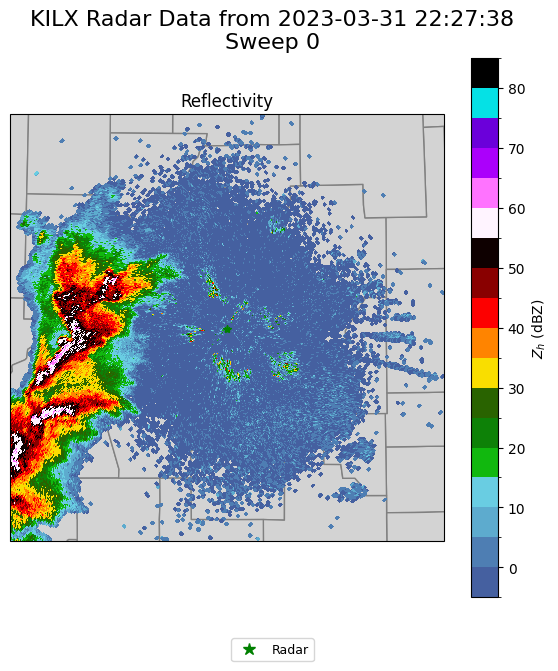

In [54]:
# Example: Using sync_SD and obtain_filtered_files with data source selection

# Set up parameters
start = "20230331T000000"
end = "20230401T060000"
buffer = 100
tor_range = (0, 5)
wind_range = (57, None)
hail_range = (1, None)

# Get radar scans
scans = radar_files(sites="KILX", start=start, end=end, download=False, save_csv=False)

# Sync with individual data sources (use only SD for this example)
sds = sync_SD(scans, data_csv="storm_data.csv", buffer_km=buffer, save_csv=True, hail_range=hail_range, tor_range=tor_range, wind_range=wind_range)

# Option 1: Filter files using only SD data
filtered_files = obtain_filtered_files(sd_info=sds, delta_constraint=15, download_files=True, download_windows=True, user_start=start, user_end=end)


# Option 2: Filter files using SD and other sources combined
# filtered_files_all = obtain_filtered_files(dat_info=dats, lsr_info=lsrs, sd_info=sds,
#                                            delta_constraint=15, download_files=False,
#                                            download_windows=False, user_start=start, user_end=end)
sync_range_images(filtered_files, gif=True, duration=1, extent=100, gdf_sd=sds)

print(f"SD synced rows: {len(sds)}")
print(f"Filtered radar files (SD only): {len(filtered_files)}")
print("sync_SD and obtain_filtered_files with data source selection are ready to use!")

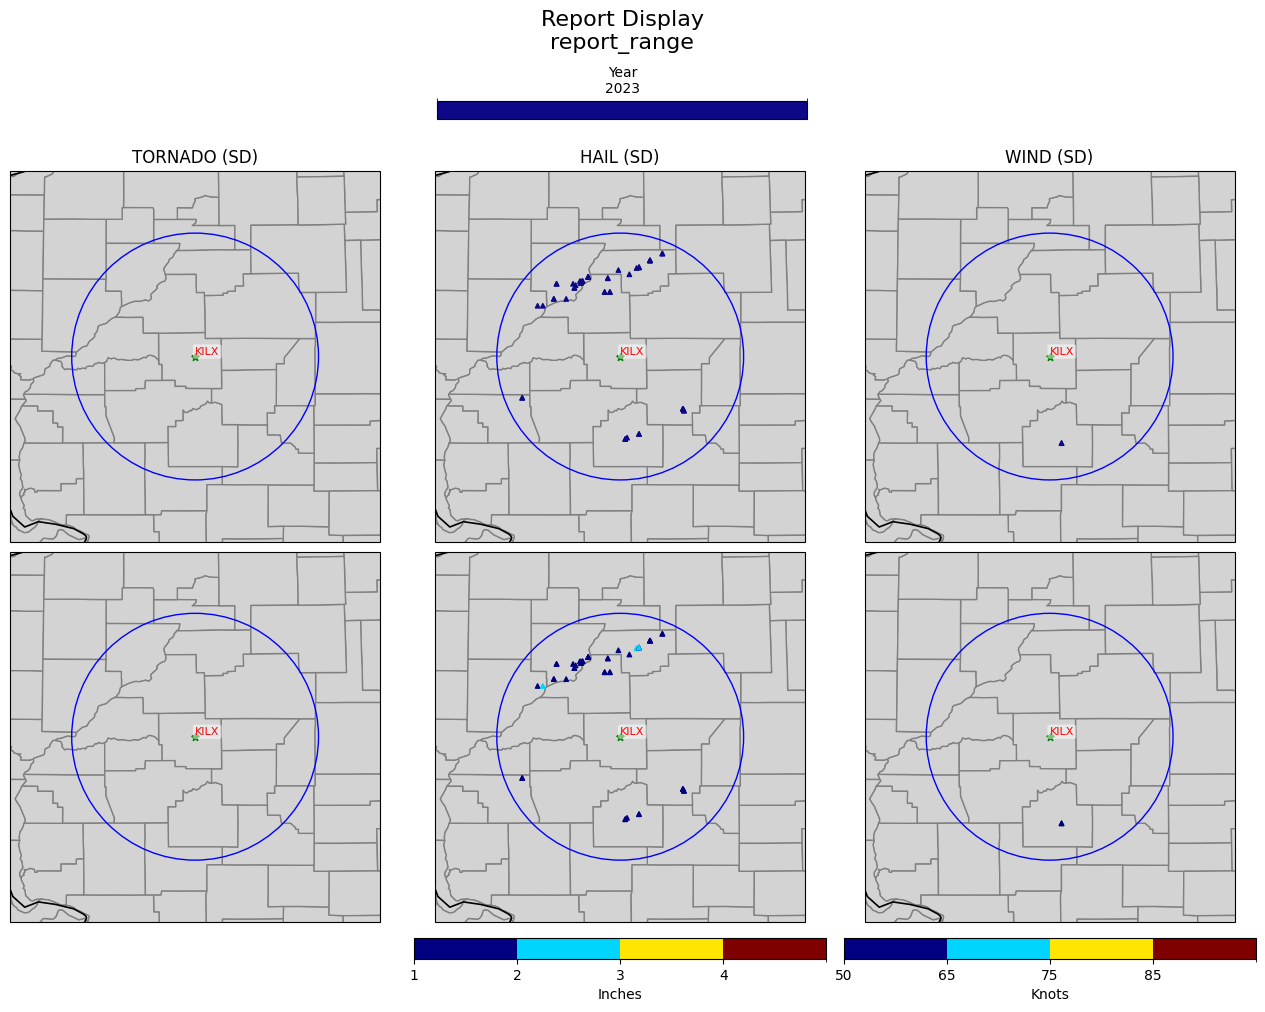

In [312]:
multi_report_display(gdf_sd=sds)

In [70]:
# Workflow example
start = "20230401T000000"
end = "20230430T235959"
buffer = 100

scans = radar_files(sites="KTLX", start=start, end=end, download=False, save_csv=True)
lsrs = sync_LSR(scans, data_csv="lsr.csv", buffer_km=buffer, save_csv=True, hail_range=(1,None))
dats = sync_DAT(scans, data_csv="dat.csv", buffer_km=buffer, save_csv=True, tor_range=(0,5), wind_range=(57,None))
filtered_files = obtain_filtered_files(dats, lsrs, delta_constraint=15, download_files=False, download_windows=True, local=False, user_start=start, user_end=end)
multi_report_display(lsrs, dats, filtered_files)


Buffer geometry created with 1 component(s).


KeyboardInterrupt: 

In [ ]:
times_list = [
    ("20240520T012500", "20240520T033500", {"left": 110, "right": 10, "bottom": 0, "top": 80}),
]

buffer = 100
tor_range = (0, 5)
wind_range = (57, None)
hail_range = (1, None)

sites = ["KTLX"]

gdf_lsr = pd.read_csv("lsr_syncs/LSR_20230124T111133_20260404T021459.csv")
gdf_dat = pd.read_csv("dat_syncs/DAT_20230124T111133_20260404T021459.csv")

alt_list = [6000]

all_gif_paths = {}

for start, end, extent in times_list:
    range_title = f"{start}_{end}"
    all_gif_paths[range_title] = {}

    print(f"\n=== Processing time window: {start} to {end} ===")

    for alt in alt_list:
        print(f"\n--- Scan type: {alt} ---")

        sync_ranges = radar_files(
            sites,
            start=start,
            end=end,
            download=False,
            save_csv=False,
            out_dir="bulk/rad_proj"
        )

        if sync_ranges.empty:
            print(f"No matched files found for {alt}.")
            all_gif_paths[range_title][alt] = {}
            continue

        sync_ranges["window_start"] = pd.to_datetime(start)
        sync_ranges["window_end"] = pd.to_datetime(end)

        print_df = (
            sync_ranges[["site", "dt_start", "dt_end"]]
            .drop_duplicates()
            .sort_values(["dt_start"])
        )

        for site, dt_start, dt_end in print_df.itertuples(index=False, name=None):
            print(f"{site}: {dt_start:%Y-%m-%d %H:%M:%S} to {dt_end:%Y-%m-%d %H:%M:%S}")

        gif_paths = sync_range_images(
            sync_ranges,
            gif_dir="GIFs",
            gif=True,
            frame_dir="images",
            duration=0.7,
            cappi_alt=alt,
            sweep=0,
            extent=extent,
            mode="detailed",
            out_dir="bulk/rad_proj",
            gdf_lsr=gdf_lsr,
            gdf_dat=gdf_dat
        )

        all_gif_paths[range_title][alt] = gif_paths


=== Processing time window: 20240520T012500 to 20240520T033500 ===

--- Scan type: 6000 ---
KTLX PPI: 2024-05-20 01:27:40 to 2024-05-20 01:28:44
KTLX PPI: 2024-05-20 01:28:52 to 2024-05-20 01:29:56
KTLX PPI: 2024-05-20 01:30:06 to 2024-05-20 01:31:09
KTLX PPI: 2024-05-20 01:31:31 to 2024-05-20 01:32:34
KTLX PPI: 2024-05-20 01:32:43 to 2024-05-20 01:33:46
KTLX PPI: 2024-05-20 01:33:55 to 2024-05-20 01:34:59
KTLX PPI: 2024-05-20 01:35:08 to 2024-05-20 01:36:12
KTLX PPI: 2024-05-20 01:36:21 to 2024-05-20 01:37:24
KTLX PPI: 2024-05-20 01:37:45 to 2024-05-20 01:38:49
KTLX PPI: 2024-05-20 01:38:57 to 2024-05-20 01:40:01
KTLX PPI: 2024-05-20 01:40:10 to 2024-05-20 01:41:14
KTLX PPI: 2024-05-20 01:41:23 to 2024-05-20 01:42:26
KTLX PPI: 2024-05-20 01:42:35 to 2024-05-20 01:43:38
KTLX PPI: 2024-05-20 01:43:47 to 2024-05-20 01:44:51
KTLX PPI: 2024-05-20 01:44:59 to 2024-05-20 01:46:04
KTLX PPI: 2024-05-20 01:46:13 to 2024-05-20 01:47:06
KTLX PPI: 2024-05-20 01:47:32 to 2024-05-20 01:48:40
KTLX P

In [ ]:
# tor2hail_1 is probably not the best case, embedded supercell more than likely
# hail close tor case may be interesting, but it will be difficult due to data jumps
# 20230227 is a QLCS, probably save for QLCS work

In [104]:
all_files = glob.glob('storm_data/*')
df_list = [pd.read_csv(f) for f in all_files]
combined_df = pd.concat(df_list, ignore_index=True)
combined_df.to_csv('storm_data.csv', index=False)

In [ ]:
raw = pd.read_csv('storm_data.csv')
dt_str = raw['BEGIN_YEARMONTH'].astype(str) + raw['BEGIN_DAY'].astype(str)
raw['begin_dt'] = pd.to_datetime(raw['BEGIN_YEAR'])